# 2D Toy Experiments

Compares **FQL**, **FBRAC**, and **QFlow** on synthetic 2-D datasets.

| Method | Policy | Critic |
|--------|--------|--------|
| FQL | One-step (distilled from flow) | Outer Q(a) |
| FBRAC | Flow (direct Q-maximization) | Outer Q(a) |
| QFlow | Flow (value gradient steering) | Inner V(x,t) + Outer Q(a) |

In [25]:
import dotenv
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


## 1. Imports

In [26]:
import sys, os, pickle
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from datasets import sample_from_dataset, plot_dataset, make_reward_fns, DOMAIN_MIN, DOMAIN_MAX
from models import integrate_flow, onestep_forward

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## 2. Configuration

In [28]:
# ── Dataset ──────────────────────────────────────────────────────────
DATASETS  = ["two_spirals", "moons", "swissroll", "eight_gaussians"]
DATASET   = "swissroll"   # default dataset for standalone cells
N_DATA    = 10_000

# ── Network ──────────────────────────────────────────────────────────
NUM_LAYERS = 4
HIDDEN_DIM = 512
FLOW_STEPS = 25           # number of ODE integration steps

# ── Training ─────────────────────────────────────────────────────────
def get_bc_epochs(dataset_type):
    return 5000 if dataset_type == "two_spirals" else 2000

BC_EPOCHS = get_bc_epochs(DATASET)
OFFLINE_EPOCHS = 100
EPOCHS         = BC_EPOCHS + OFFLINE_EPOCHS
LEARNING_RATE  = 3e-4
BATCH_SIZE     = 4096

# ── Evaluation / Logging ─────────────────────────────────────────────
NUM_EVALS  = 512
NUM_PLOTS  = 0            # progress snapshots saved during training
PLOT_STEP  = EPOCHS // NUM_PLOTS if NUM_PLOTS > 0 else None

# ── Regularisation ──────────────────────────────────────────────────
ALPHAS             = [5.0, 1.0, 0.5, 0.3]  # BC regularization / Guidance coefficients to sweep
USE_TARGET_NETWORK = False
TAU                = 0.005

# ── Output ───────────────────────────────────────────────────────────
SAVE_DIR = "toy_experiment"


## 3. Dataset

Dataset: two_spirals  |  N=10000


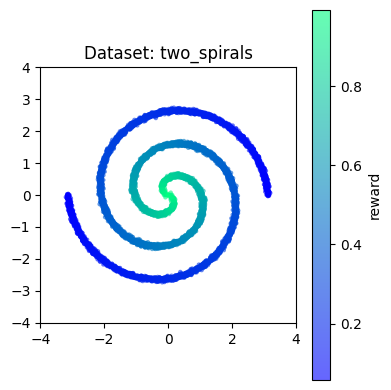

Dataset: moons  |  N=10000


<Figure size 640x480 with 0 Axes>

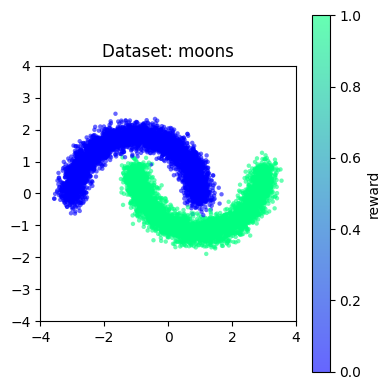

Dataset: swissroll  |  N=10000


<Figure size 640x480 with 0 Axes>

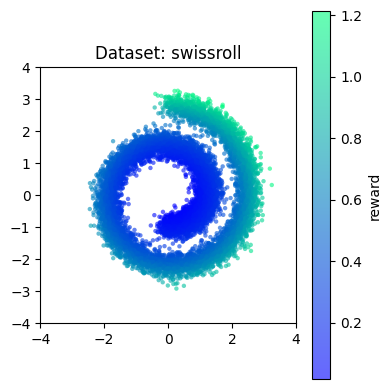

Dataset: eight_gaussians  |  N=10000


<Figure size 640x480 with 0 Axes>

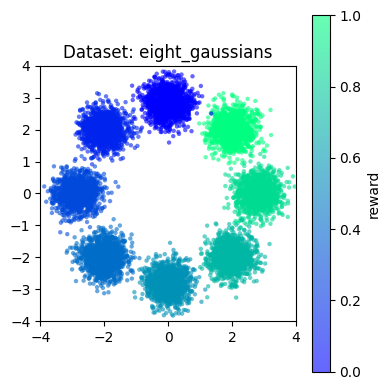

<Figure size 640x480 with 0 Axes>

In [29]:
for DATASET in DATASETS:
    np.random.seed(0)
    x_1_data, rewards_data = sample_from_dataset(N_DATA, DATASET)
    rewards_data = np.array(rewards_data).flatten()

    print(f"Dataset: {DATASET}  |  N={len(x_1_data)}")

    _, reward_fn_vec = make_reward_fns(DATASET)

    fig, ax = plt.subplots(figsize=(4, 4))
    sc = ax.scatter(x_1_data[:, 0], x_1_data[:, 1],
                    c=rewards_data, cmap="winter", s=10, alpha=0.6, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="reward")
    ax.set_title(f"Dataset: {DATASET}")
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

    out_dir = f"{SAVE_DIR}/{DATASET}"
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f"{out_dir}/dataset_samples.png", dpi=200, bbox_inches="tight")

In [30]:
fql_results   = []   # (alpha, policy_params, bc_policy_params)
fql_histories = {}   # alpha -> history dict

for alpha in ALPHAS:
    pkl_path = (
        f"{SAVE_DIR}/{DATASET}/fql/"
        f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
        f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl"
    )
    with open(pkl_path, "rb") as f:
        ckpt = pickle.load(f)
    fql_results.append((alpha, ckpt["policy_params"], ckpt["bc_policy_params"]))
    fql_histories[alpha] = ckpt["history"]
    print(f"Loaded FQL  alpha={alpha}   xfrom  {pkl_path}")

Loaded FQL  alpha=5.0   xfrom  toy_experiment/eight_gaussians/fql/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=1.0   xfrom  toy_experiment/eight_gaussians/fql/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.5   xfrom  toy_experiment/eight_gaussians/fql/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.3   xfrom  toy_experiment/eight_gaussians/fql/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl


In [31]:
fbrac_results   = []   # (alpha, flow_params, bc_policy_params)
fbrac_histories = {}

for alpha in ALPHAS:
    pkl_path = (
        f"{SAVE_DIR}/{DATASET}/fbrac/"
        f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
        f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl"
    )
    with open(pkl_path, "rb") as f:
        ckpt = pickle.load(f)
    fbrac_results.append((alpha, ckpt["flow_params"], ckpt["bc_policy_params"]))
    fbrac_histories[alpha] = ckpt["history"]
    print(f"Loaded FBRAC  alpha={alpha}  from  {pkl_path}")

Loaded FBRAC  alpha=5.0  from  toy_experiment/eight_gaussians/fbrac/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=1.0  from  toy_experiment/eight_gaussians/fbrac/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=0.5  from  toy_experiment/eight_gaussians/fbrac/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=0.3  from  toy_experiment/eight_gaussians/fbrac/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl


In [32]:
qflow_results   = []   # (alpha, flow_params, bc_policy_params)
qflow_histories = {}

for alpha in ALPHAS:
    pkl_path = (
        f"{SAVE_DIR}/{DATASET}/qflow/"
        f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
        f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl"
    )
    with open(pkl_path, "rb") as f:
        ckpt = pickle.load(f)
    qflow_results.append((alpha, ckpt["flow_params"], ckpt["bc_policy_params"]))
    qflow_histories[alpha] = ckpt["history"]
    print(f"Loaded QFlow  lambda={alpha}  from  {pkl_path}")

Loaded QFlow  lambda=5.0  from  toy_experiment/eight_gaussians/qflow/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded QFlow  lambda=1.0  from  toy_experiment/eight_gaussians/qflow/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded QFlow  lambda=0.5  from  toy_experiment/eight_gaussians/qflow/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded QFlow  lambda=0.3  from  toy_experiment/eight_gaussians/qflow/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl


## 4. Load Saved Models

Loads weights + training histories from pkl files written by the CLI scripts (`run_fql.py`, `run_fbrac.py`, `run_qflow.py`).  
Make sure the pkl files exist for the configured `DATASET`, `ALPHAS`, `FLOW_STEPS`, `NUM_LAYERS`, `HIDDEN_DIM`, `N_DATA`, and `EPOCHS`.


Loading saved models for dataset: two_spirals (EPOCHS=5100)
Loaded FQL  alpha=5.0  from  toy_experiment/two_spirals/fql/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FQL  alpha=1.0  from  toy_experiment/two_spirals/fql/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FQL  alpha=0.5  from  toy_experiment/two_spirals/fql/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FQL  alpha=0.3  from  toy_experiment/two_spirals/fql/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FBRAC  alpha=5.0  from  toy_experiment/two_spirals/fbrac/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FBRAC  alpha=1.0  from  toy_experiment/two_spirals/fbrac/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FBRAC  alpha=0.5  from  toy_experiment/two_spirals/fbrac/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs5100.pkl
Loaded FBRAC  alpha=0.3  from  toy_exp

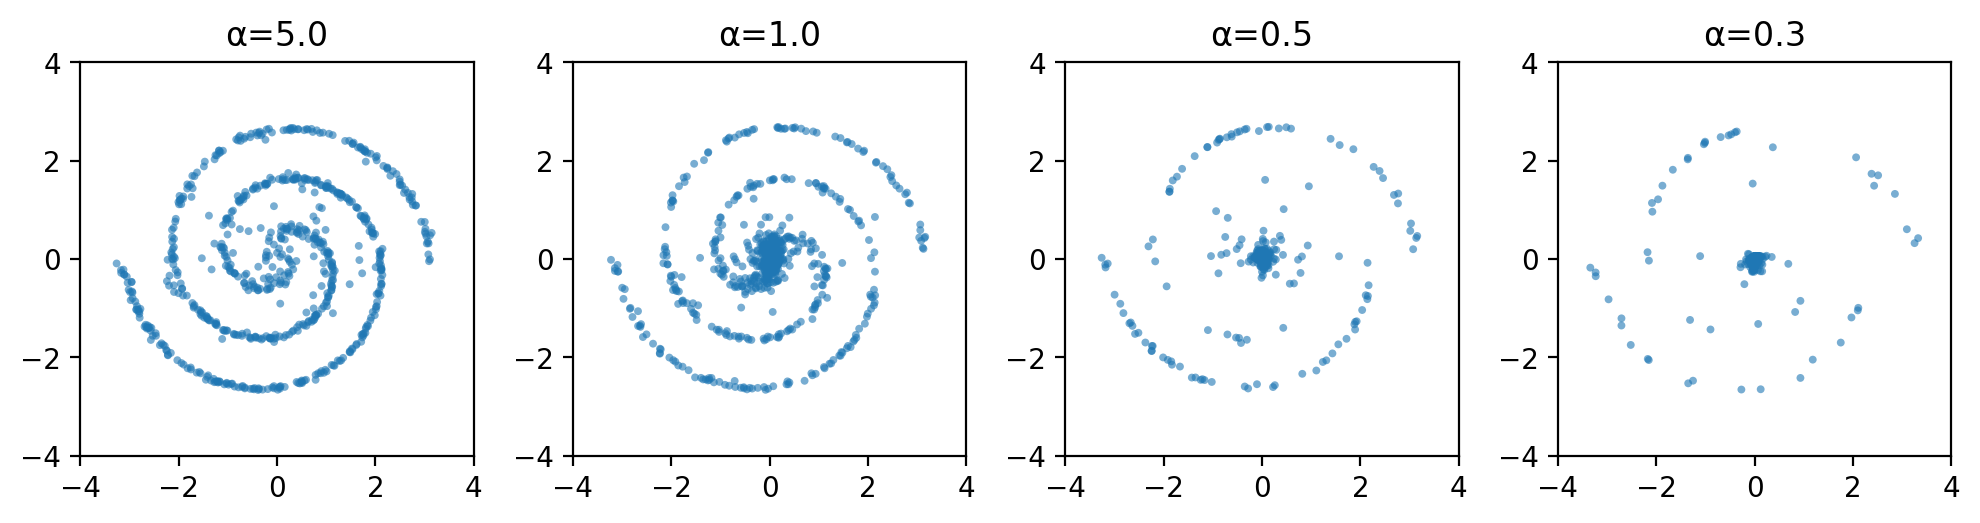

Saved to toy_experiment/two_spirals/two_spirals_fbrac_comparison.pdf


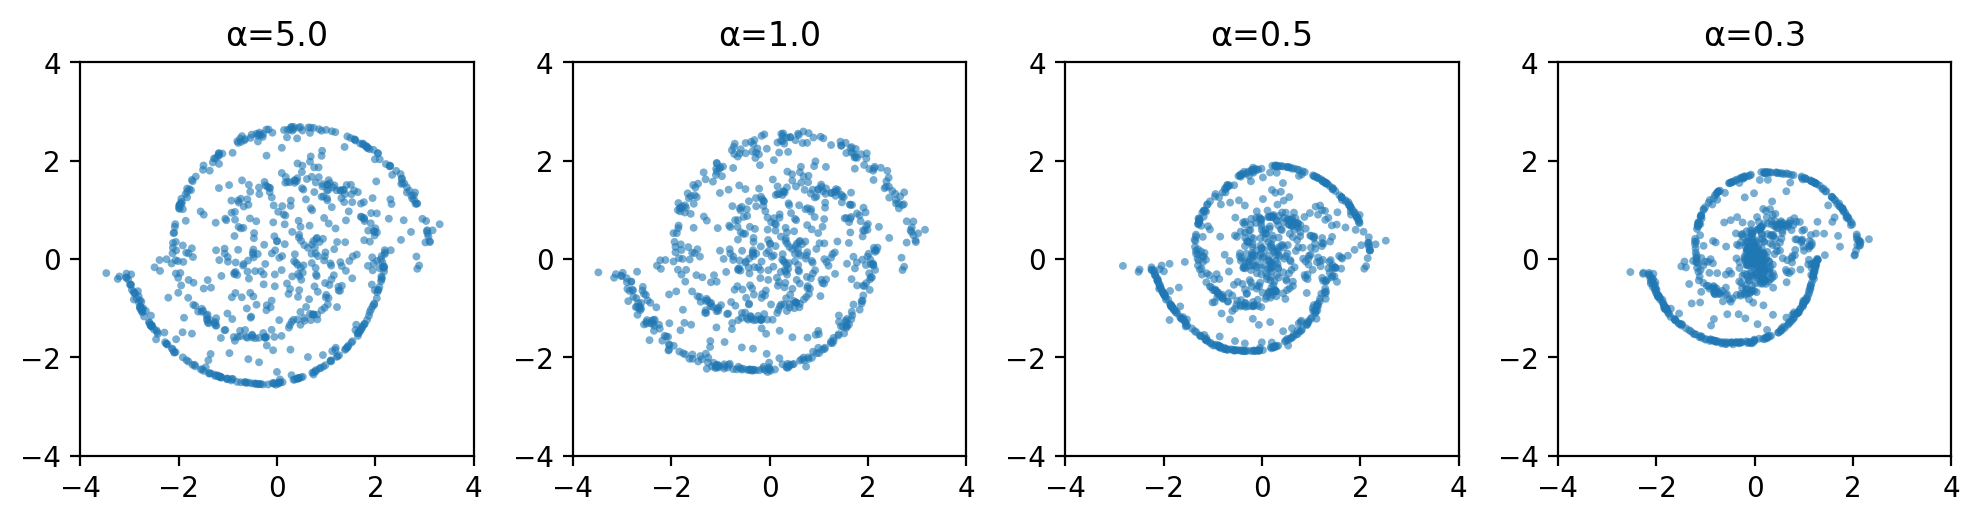

Saved to toy_experiment/two_spirals/two_spirals_fql_comparison.pdf


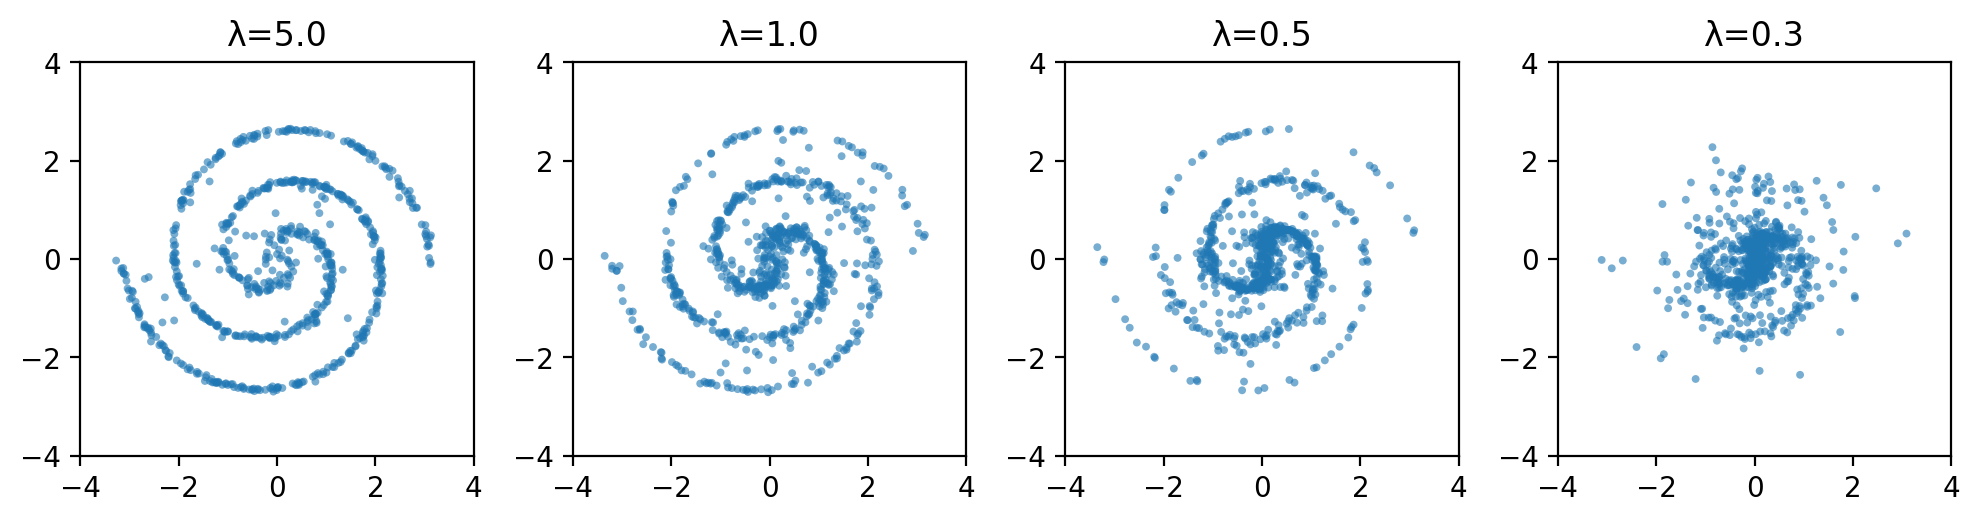

Saved to toy_experiment/two_spirals/two_spirals_qflow_comparison.pdf

Loading saved models for dataset: moons (EPOCHS=2100)
Loaded FQL  alpha=5.0  from  toy_experiment/moons/fql/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=1.0  from  toy_experiment/moons/fql/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.5  from  toy_experiment/moons/fql/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.3  from  toy_experiment/moons/fql/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=5.0  from  toy_experiment/moons/fbrac/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=1.0  from  toy_experiment/moons/fbrac/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=0.5  from  toy_experiment/moons/fbrac/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alp

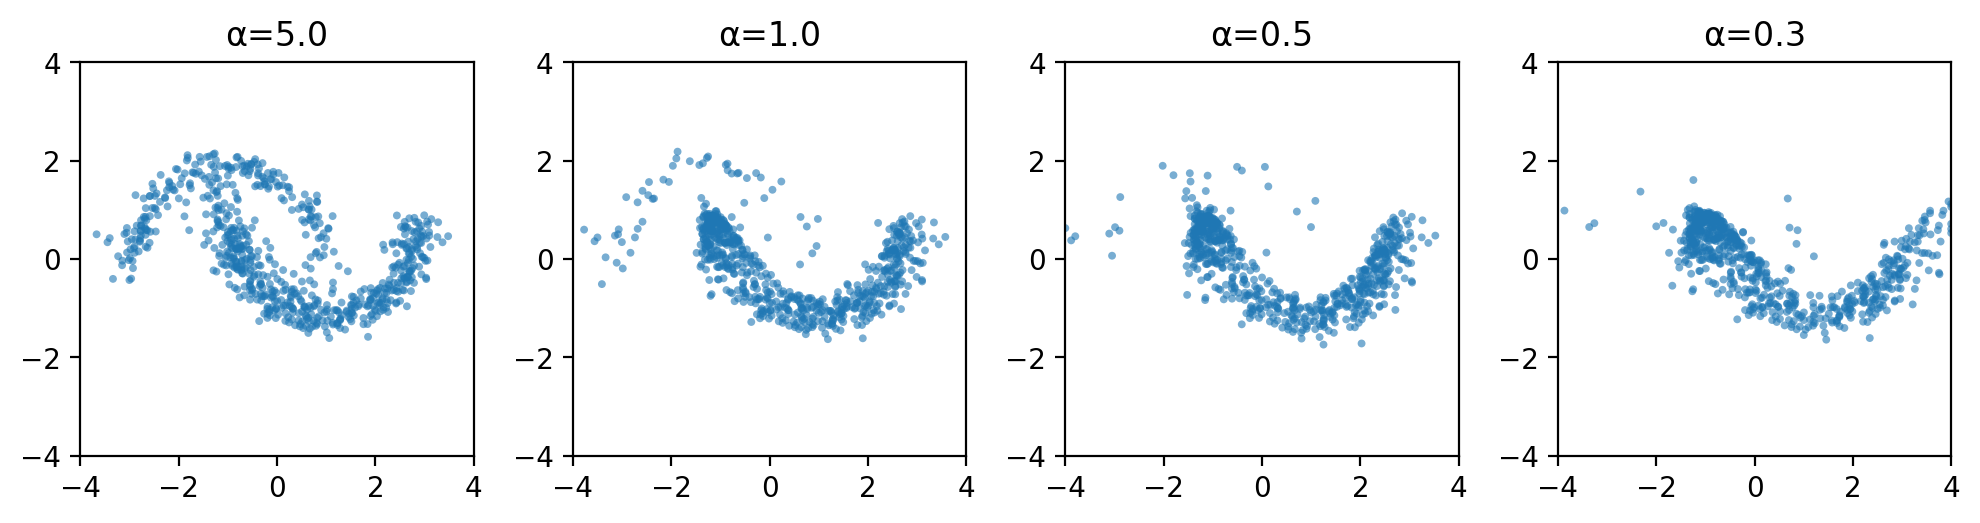

Saved to toy_experiment/moons/moons_fbrac_comparison.pdf


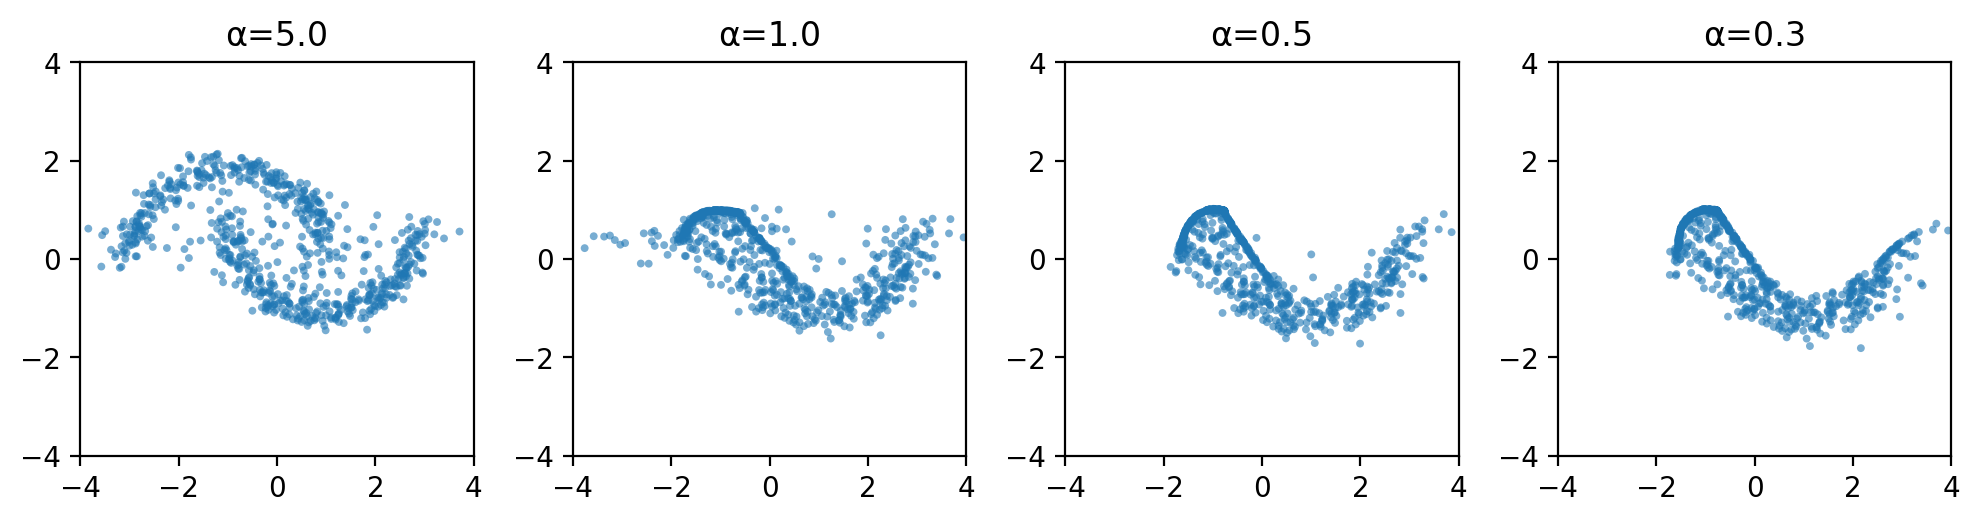

Saved to toy_experiment/moons/moons_fql_comparison.pdf


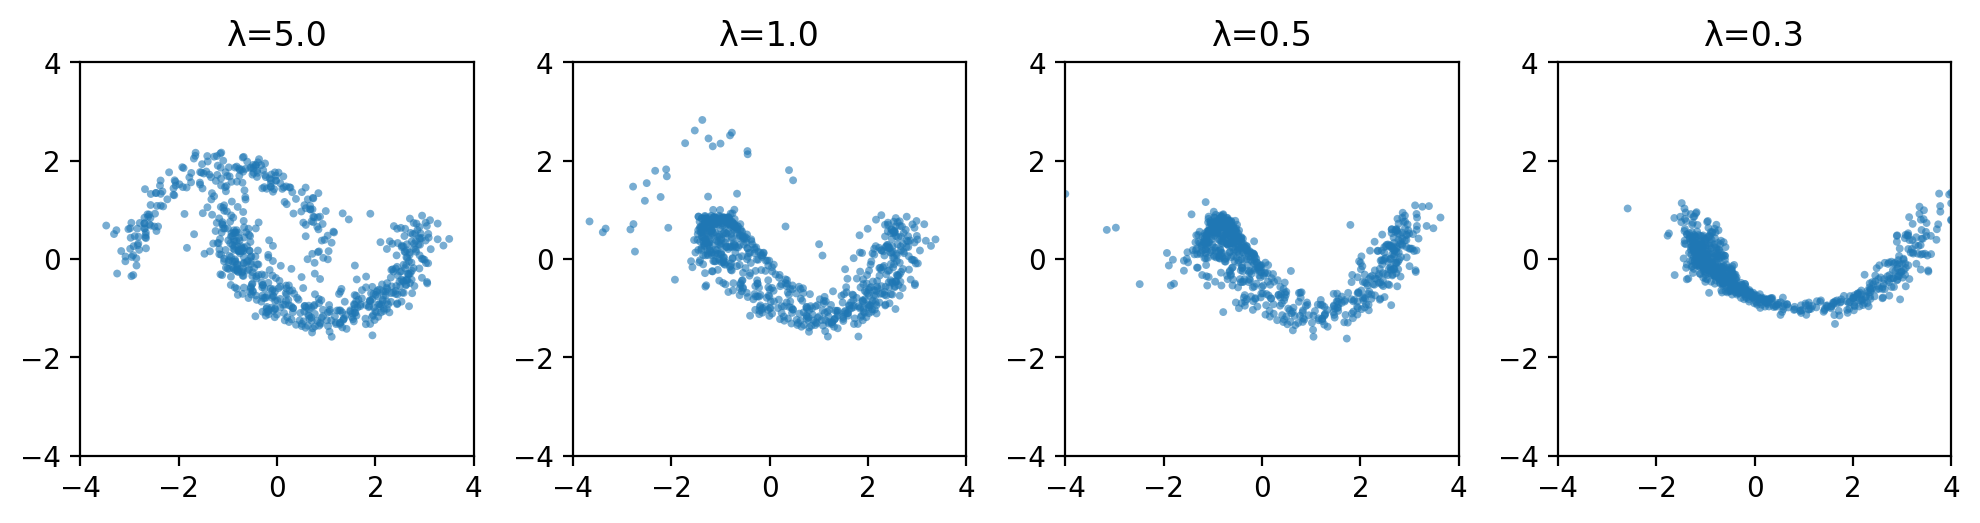

Saved to toy_experiment/moons/moons_qflow_comparison.pdf

Loading saved models for dataset: swissroll (EPOCHS=2100)
Loaded FQL  alpha=5.0  from  toy_experiment/swissroll/fql/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=1.0  from  toy_experiment/swissroll/fql/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.5  from  toy_experiment/swissroll/fql/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.3  from  toy_experiment/swissroll/fql/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=5.0  from  toy_experiment/swissroll/fbrac/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=1.0  from  toy_experiment/swissroll/fbrac/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=0.5  from  toy_experiment/swissroll/fbrac/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.p

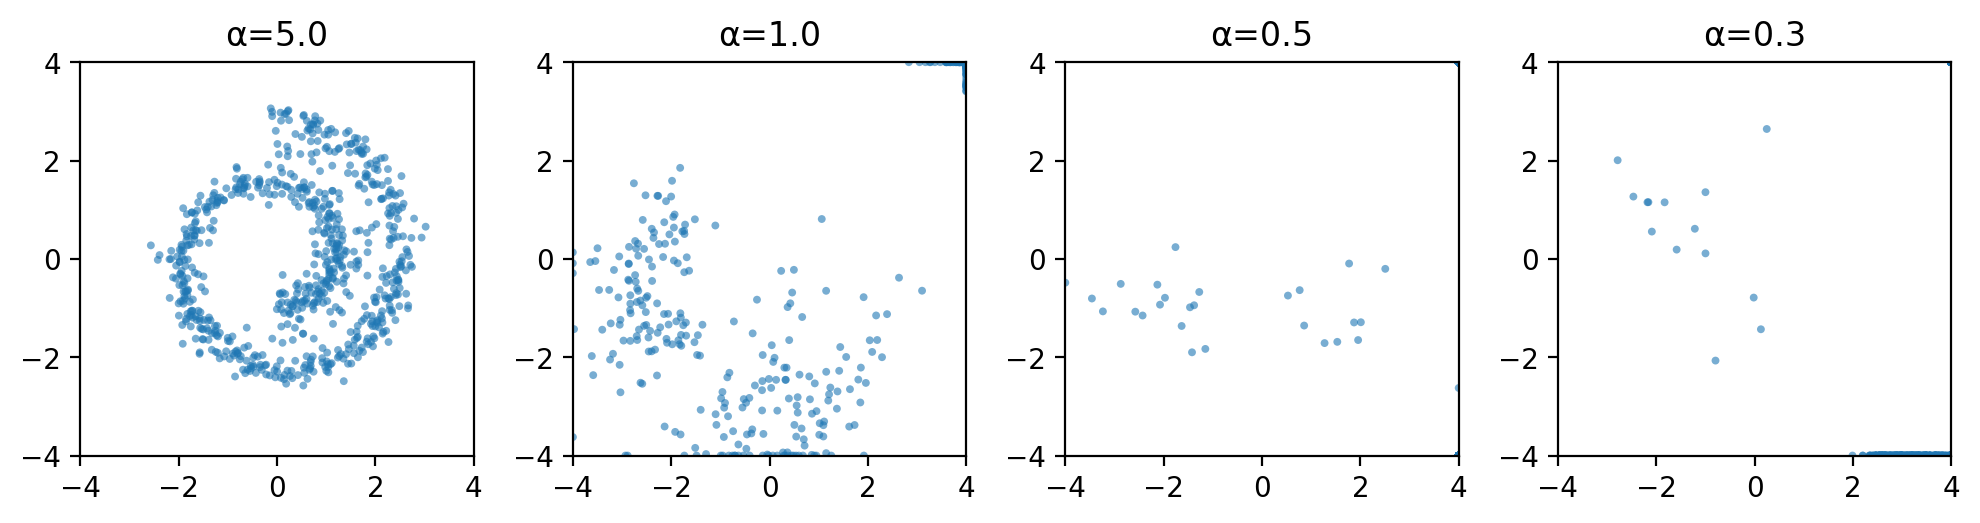

Saved to toy_experiment/swissroll/swissroll_fbrac_comparison.pdf


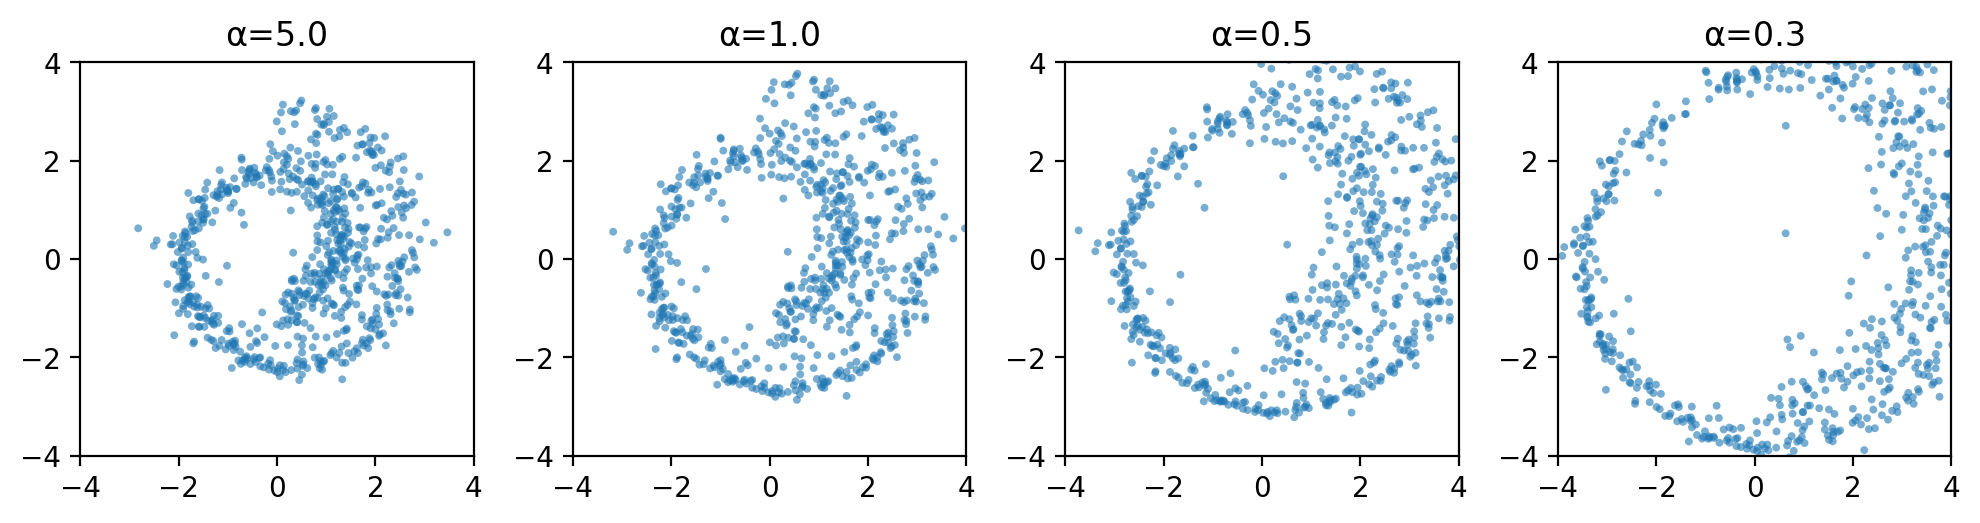

Saved to toy_experiment/swissroll/swissroll_fql_comparison.pdf


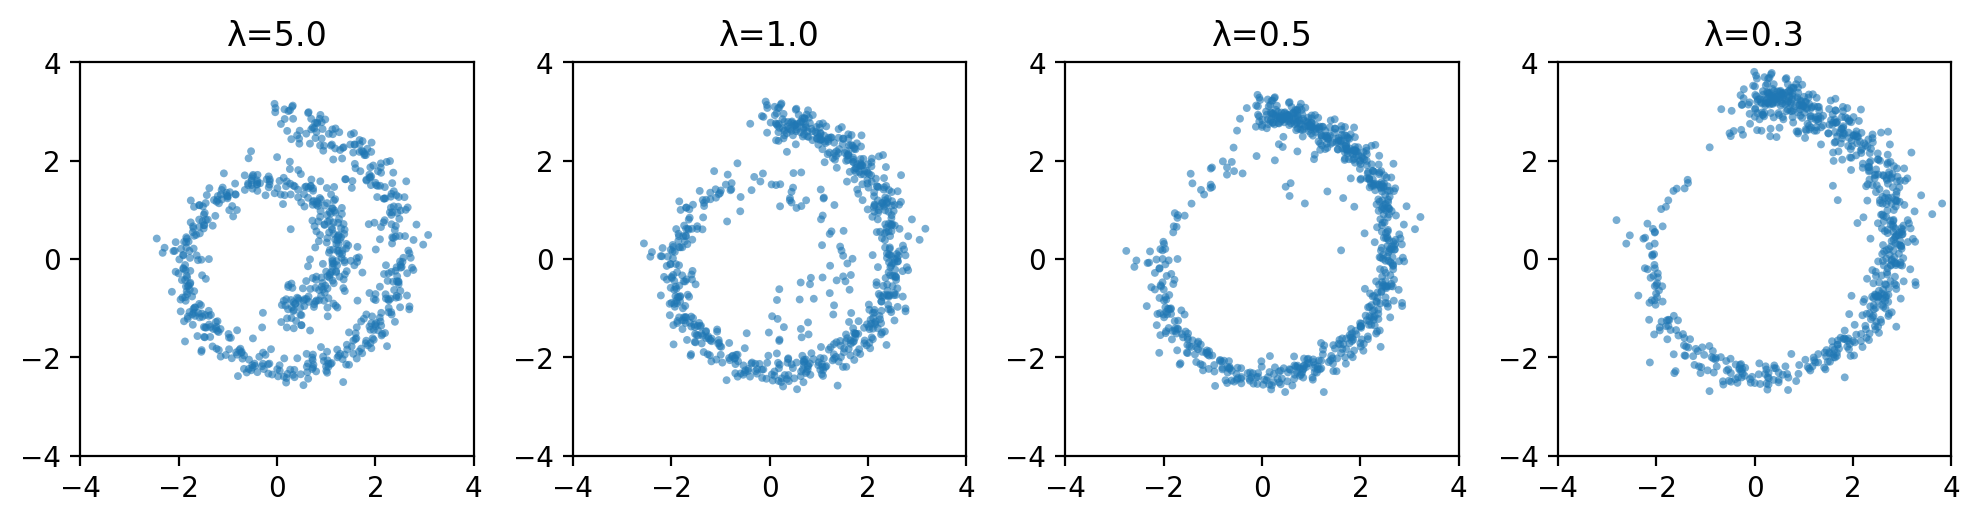

Saved to toy_experiment/swissroll/swissroll_qflow_comparison.pdf

Loading saved models for dataset: eight_gaussians (EPOCHS=2100)
Loaded FQL  alpha=5.0  from  toy_experiment/eight_gaussians/fql/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=1.0  from  toy_experiment/eight_gaussians/fql/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.5  from  toy_experiment/eight_gaussians/fql/weights_alpha0.5_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FQL  alpha=0.3  from  toy_experiment/eight_gaussians/fql/weights_alpha0.3_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=5.0  from  toy_experiment/eight_gaussians/fbrac/weights_alpha5.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=1.0  from  toy_experiment/eight_gaussians/fbrac/weights_alpha1.0_flow25_layers4_hidden512_data10000_epochs2100.pkl
Loaded FBRAC  alpha=0.5  from  toy_experiment/eight_gaussians/fbrac/weights_

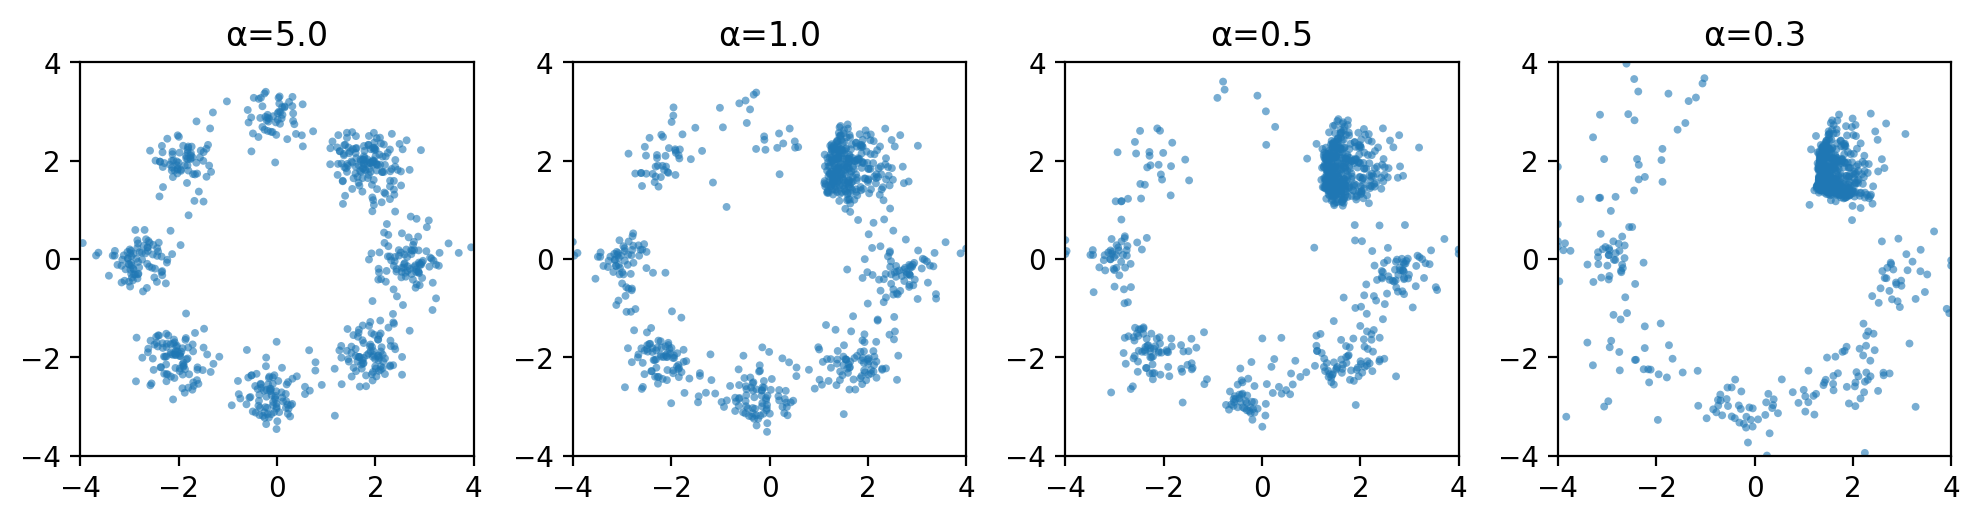

Saved to toy_experiment/eight_gaussians/eight_gaussians_fbrac_comparison.pdf


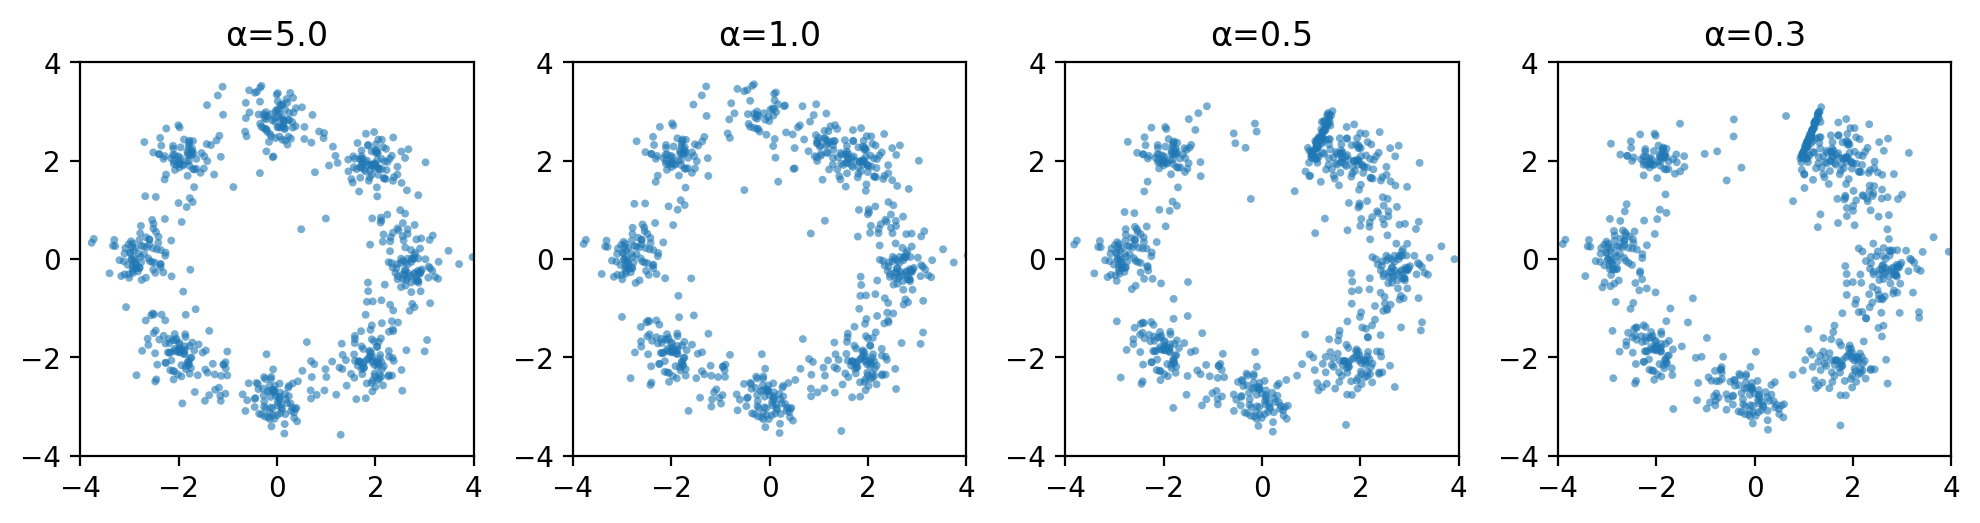

Saved to toy_experiment/eight_gaussians/eight_gaussians_fql_comparison.pdf


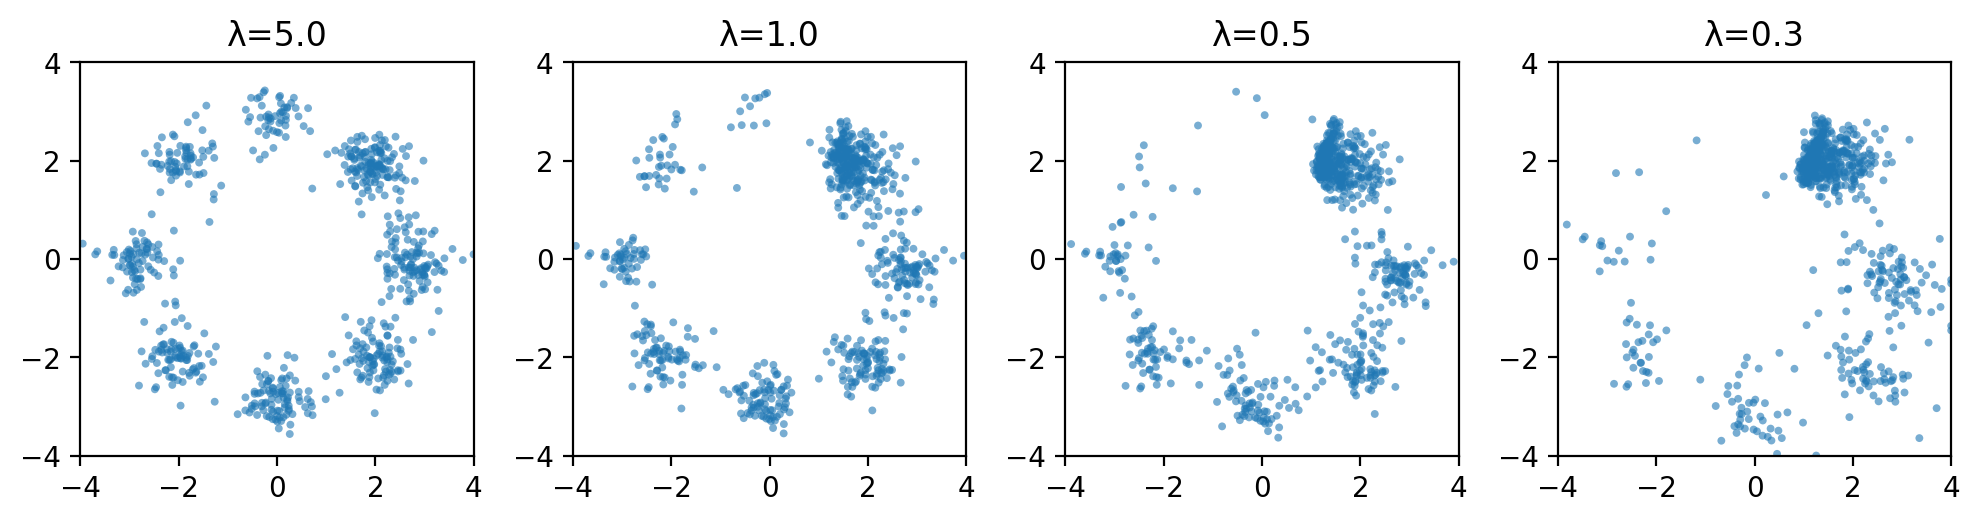

Saved to toy_experiment/eight_gaussians/eight_gaussians_qflow_comparison.pdf


In [33]:
NUM_EVALS = 700

for DATASET in DATASETS:
    bc_epochs = get_bc_epochs(DATASET)
    epochs = bc_epochs + OFFLINE_EPOCHS

    print(f"\nLoading saved models for dataset: {DATASET} (EPOCHS={epochs})")

    fql_results   = []
    fql_histories = {}
    for alpha in ALPHAS:
        pkl_path = (
            f"{SAVE_DIR}/{DATASET}/fql/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(pkl_path, "rb") as f:
            ckpt = pickle.load(f)
        fql_results.append((alpha, ckpt["policy_params"], ckpt["bc_policy_params"]))
        fql_histories[alpha] = ckpt["history"]
        print(f"Loaded FQL  alpha={alpha}  from  {pkl_path}")

    fbrac_results   = []
    fbrac_histories = {}
    for alpha in ALPHAS:
        pkl_path = (
            f"{SAVE_DIR}/{DATASET}/fbrac/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(pkl_path, "rb") as f:
            ckpt = pickle.load(f)
        fbrac_results.append((alpha, ckpt["flow_params"], ckpt["bc_policy_params"]))
        fbrac_histories[alpha] = ckpt["history"]
        print(f"Loaded FBRAC  alpha={alpha}  from  {pkl_path}")

    qflow_results   = []
    qflow_histories = {}
    for alpha in ALPHAS:
        pkl_path = (
            f"{SAVE_DIR}/{DATASET}/qflow/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(pkl_path, "rb") as f:
            ckpt = pickle.load(f)
        qflow_results.append((alpha, ckpt["flow_params"], ckpt["bc_policy_params"]))
        qflow_histories[alpha] = ckpt["history"]
        print(f"Loaded QFlow  lambda={alpha}  from  {pkl_path}")

    z_eval = jrandom.normal(jrandom.PRNGKey(0), (NUM_EVALS, 2))
    methods = [
        ("FBRAC", fbrac_results,  lambda p: np.array(integrate_flow(p, z_eval, steps=FLOW_STEPS))),
        ("FQL",   fql_results,   lambda p: np.array(onestep_forward(p, z_eval))),
        ("QFlow", qflow_results,  lambda p: np.array(integrate_flow(p, z_eval, steps=FLOW_STEPS))),
    ]

    for name, results, sample_fn in methods:
        results_sorted = sorted(results, key=lambda x: x[0], reverse=True)

        n_cols = len(ALPHAS)
        n_rows = 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows), dpi=200)

        for col, (alpha, policy_params, _) in enumerate(results_sorted):
            actions = sample_fn(policy_params)
            axes[col].scatter(actions[:, 0], actions[:, 1],
                              s=8, alpha=0.6, edgecolors="none")
            if name == "QFlow":  # guidance coefficient lambda
                axes[col].set_title(f"λ={alpha}", fontsize=12)
            else:
                axes[col].set_title(f"α={alpha}", fontsize=12)
            axes[col].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
            axes[col].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            axes[col].set_aspect("equal")

        plt.tight_layout()

        out_dir = f"{SAVE_DIR}/{DATASET}"
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(f"{out_dir}/{DATASET.lower()}_{name.lower()}_comparison.pdf", dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved to {out_dir}/{DATASET.lower()}_{name.lower()}_comparison.pdf")


## 6. Policy Gradient Norm Analysis (Offline RL Only)

For each α value, plot the policy gradient norm over offline RL epochs only (after BC training).  
Lines: FBRAC (light purple), FQL (light green), QFlow (light blue).


Plotting policy gradient norms for dataset: two_spirals (EPOCHS=5100)


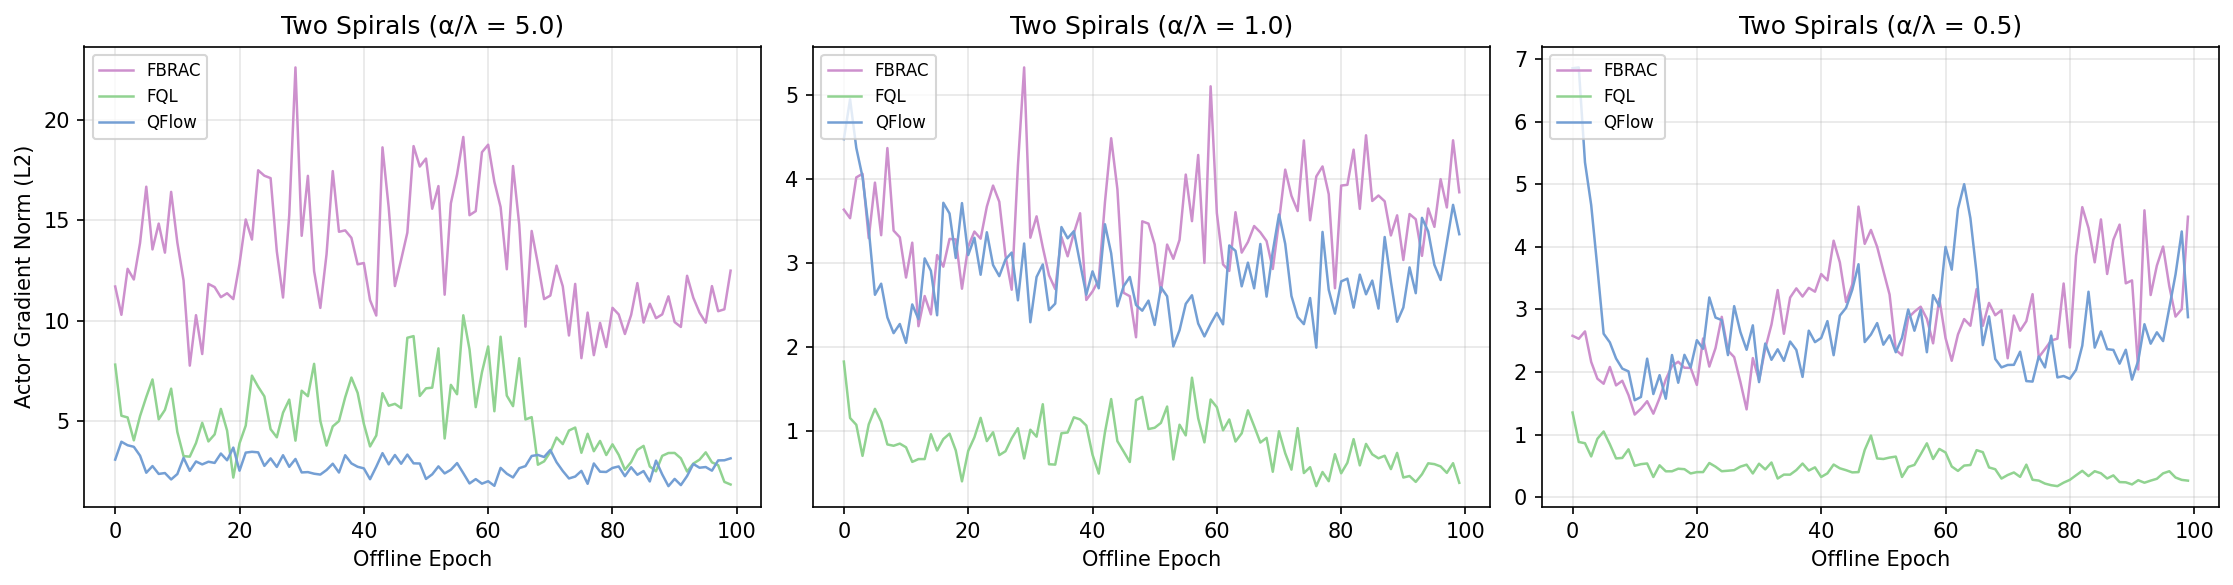

Saved to toy_experiment/two_spirals/policy_grad_norms_offline.png

Plotting policy gradient norms for dataset: moons (EPOCHS=2100)


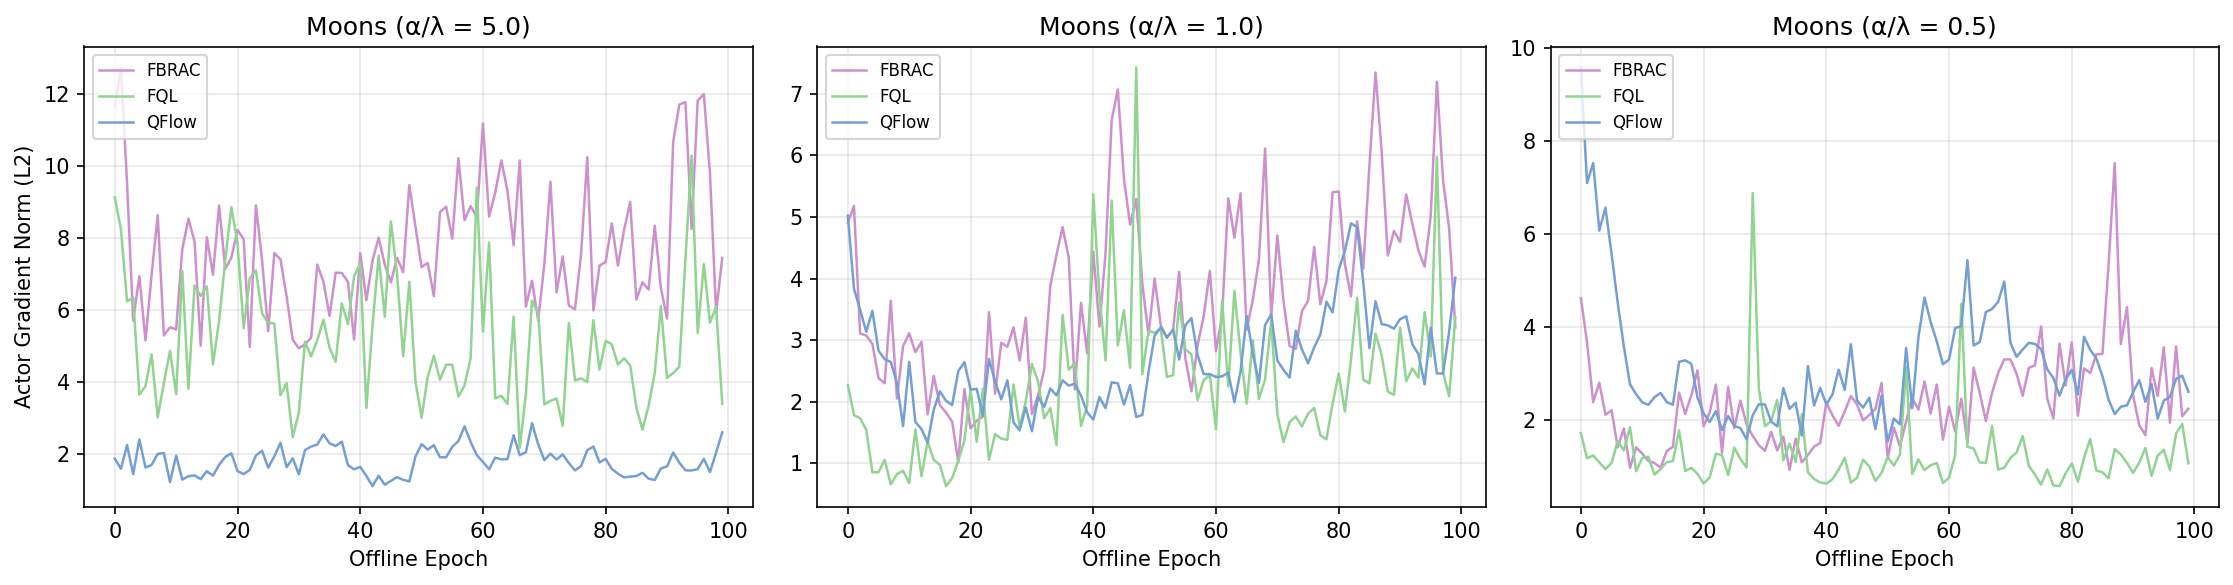

Saved to toy_experiment/moons/policy_grad_norms_offline.png

Plotting policy gradient norms for dataset: swissroll (EPOCHS=2100)


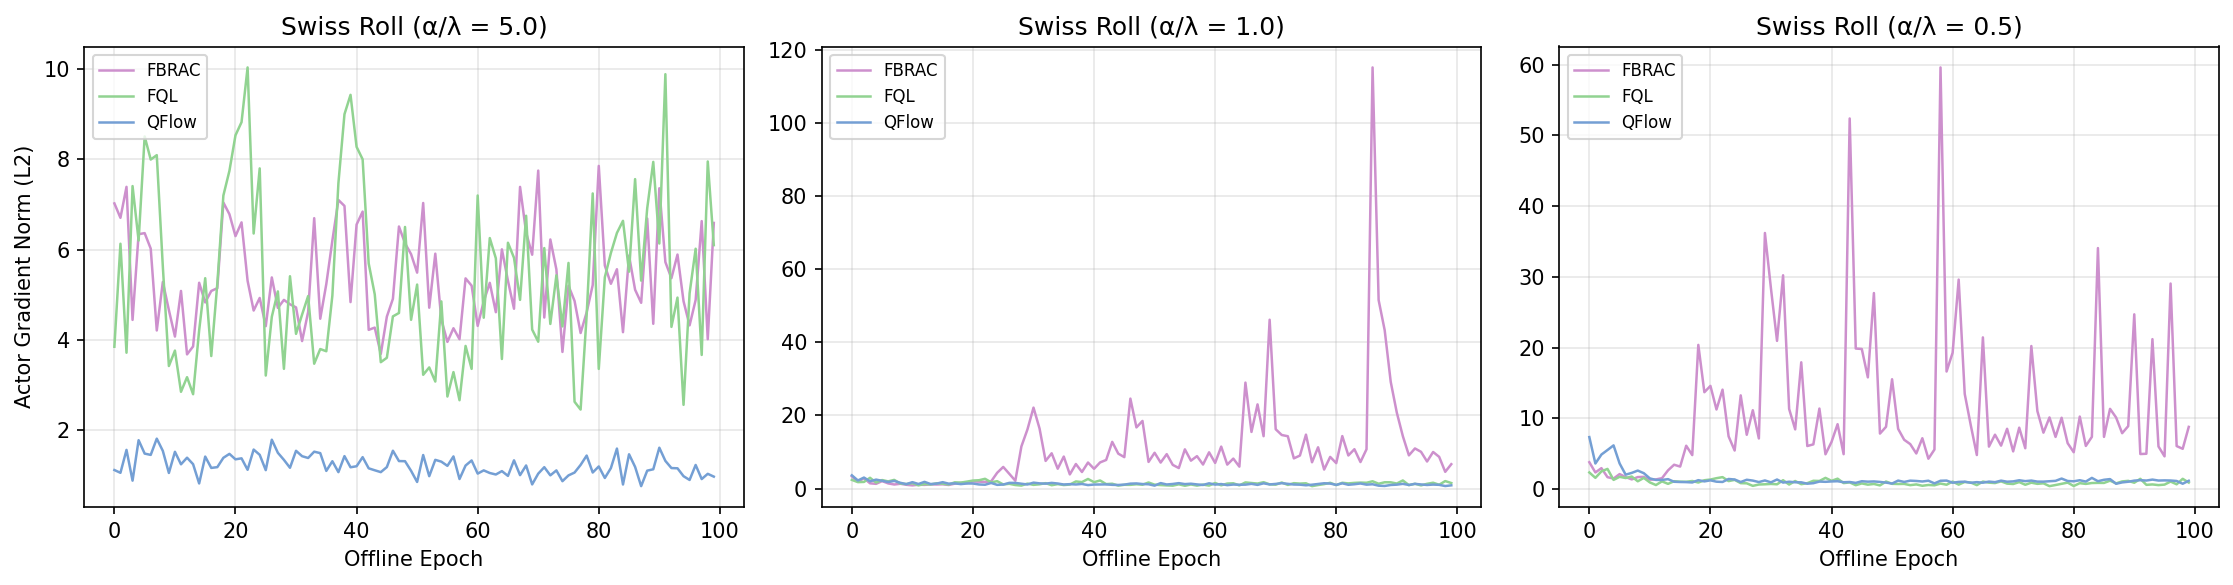

Saved to toy_experiment/swissroll/policy_grad_norms_offline.png

Plotting policy gradient norms for dataset: eight_gaussians (EPOCHS=2100)


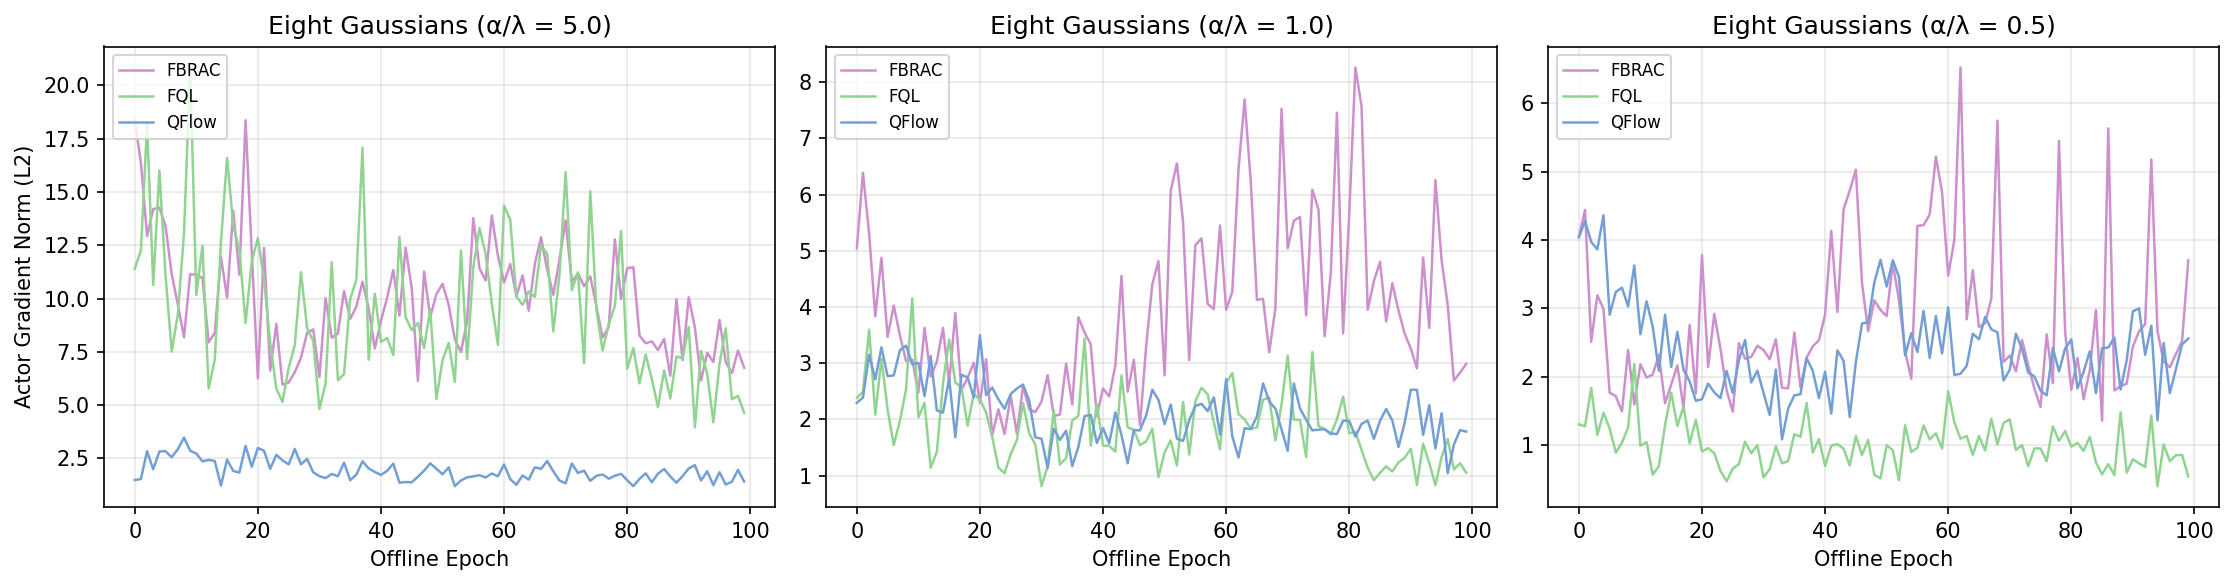

Saved to toy_experiment/eight_gaussians/policy_grad_norms_offline.png


In [121]:
ALPHAS = [5.0, 1.0, 0.5]
dataset_labels = {
    "two_spirals": "Two Spirals",
    "moons": "Moons",
    "swissroll": "Swiss Roll",
    "eight_gaussians": "Eight Gaussians",
}

# Policy gradient norms per method
policy_grad_keys = {
    "FQL":   "policy_grad_norm",    # student policy
    "FBRAC": "flow_grad_norm",      # flow policy
    "QFlow": "flow_grad_norm",      # flow policy
}

# Colors and order: FBRAC (light purple), FQL (light green), QFlow (light blue)
method_colors = {
    "FBRAC": "#CD90CD",  # light purple
    "FQL":   "#91D391",  # light green
    "QFlow": "#749FD4",  # light blue
}
method_order = ["FBRAC", "FQL", "QFlow"]

for DATASET in DATASETS:
    bc_epochs = get_bc_epochs(DATASET)
    epochs = bc_epochs + OFFLINE_EPOCHS

    print(f"\nPlotting policy gradient norms for dataset: {DATASET} (EPOCHS={epochs})")

    fql_histories = {}
    fbrac_histories = {}
    qflow_histories = {}

    for alpha in ALPHAS:
        fql_path = (
            f"{SAVE_DIR}/{DATASET}/fql/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(fql_path, "rb") as f:
            ckpt = pickle.load(f)
        fql_histories[alpha] = ckpt["history"]

        fbrac_path = (
            f"{SAVE_DIR}/{DATASET}/fbrac/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(fbrac_path, "rb") as f:
            ckpt = pickle.load(f)
        fbrac_histories[alpha] = ckpt["history"]

        qflow_path = (
            f"{SAVE_DIR}/{DATASET}/qflow/"
            f"weights_alpha{alpha}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
            f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{epochs}.pkl"
        )
        with open(qflow_path, "rb") as f:
            ckpt = pickle.load(f)
        qflow_histories[alpha] = ckpt["history"]

    n_cols = len(ALPHAS)
    n_rows = 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4), squeeze=False, dpi=150)

    for col, alpha in enumerate(ALPHAS):
        ax = axes[0, col]
        for method_name in method_order:
            grad_key = policy_grad_keys[method_name]
            histories = {
                "FQL": fql_histories,
                "FBRAC": fbrac_histories,
                "QFlow": qflow_histories,
            }[method_name]

            vals = histories[alpha].get(grad_key, [])
            offline_vals = vals[bc_epochs:] if len(vals) > bc_epochs else vals
            ax.plot(offline_vals, label=f"{method_name}", color=method_colors[method_name], linewidth=1.2)

        ax.set_title(f"{dataset_labels.get(DATASET, DATASET)} (α/λ = {alpha})", fontsize=12)
        ax.set_xlabel("Offline Epoch")
        if col == 0:
            ax.set_ylabel("Actor Gradient Norm (L2)")
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out_dir = f"{SAVE_DIR}/{DATASET}"
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(f"{out_dir}/policy_grad_norms_offline.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Saved to {out_dir}/policy_grad_norms_offline.png")

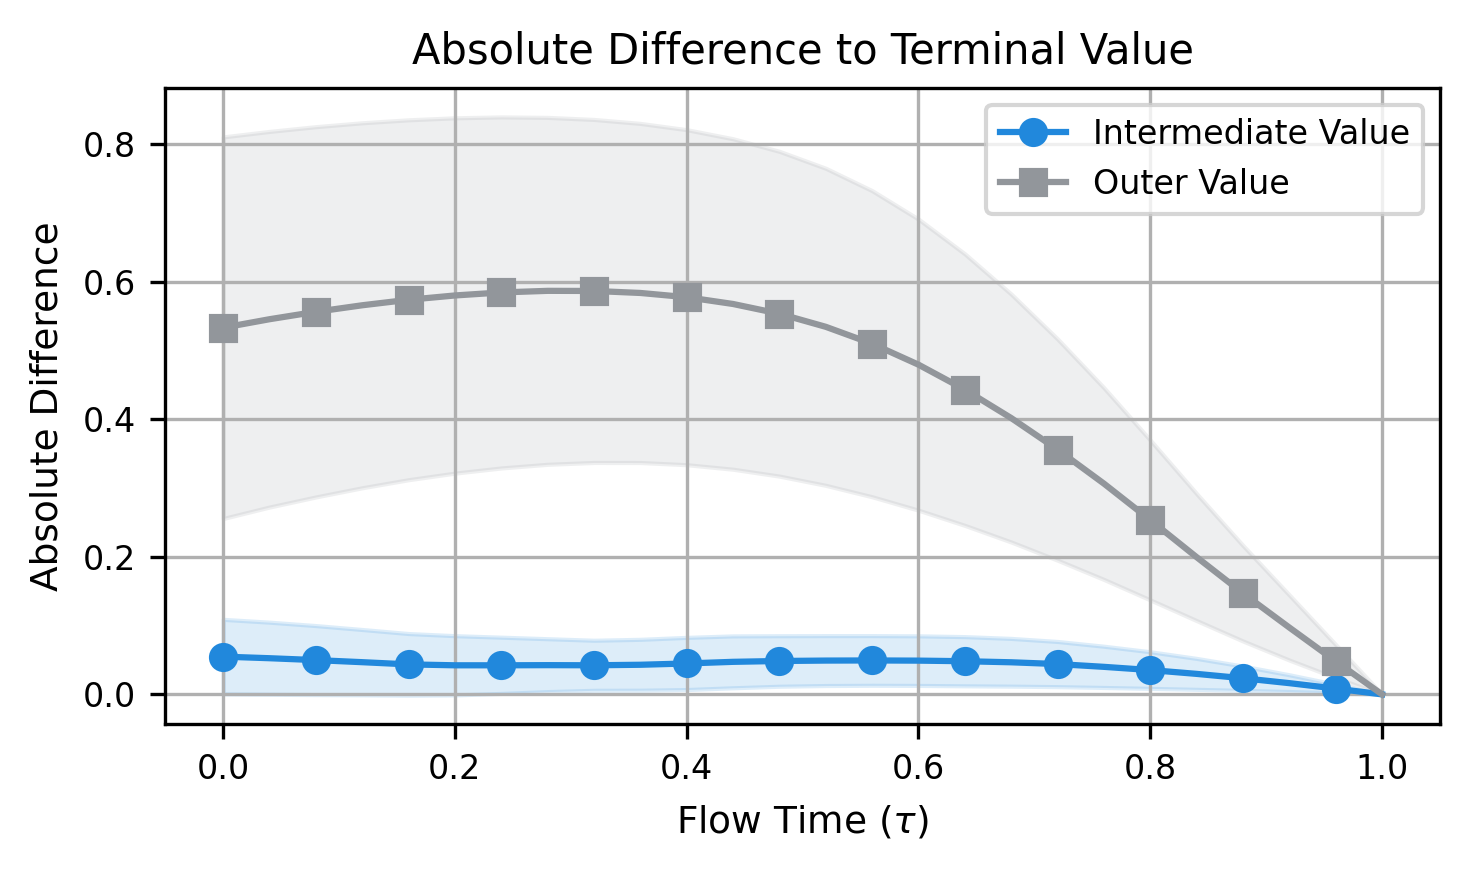

Saved to value_difference_alpha0.5.pdf


In [40]:
import pickle
from models import apply_mlp, flow_forward

# ── Select configuration ──────────────────────────────────────────────
ALPHA_PLOT   = 0.5
DATASET_PLOT = 'swissroll'

# ── Load QFlow checkpoint ─────────────────────────────────────────────
_bc_epochs = get_bc_epochs(DATASET_PLOT)
_epochs    = _bc_epochs + OFFLINE_EPOCHS
_qflow_pkl = (
    f"{SAVE_DIR}/{DATASET_PLOT}/qflow/"
    f"weights_alpha{ALPHA_PLOT}_flow{FLOW_STEPS}_layers{NUM_LAYERS}"
    f"_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{_epochs}.pkl"
)
with open(_qflow_pkl, "rb") as f:
    _qflow_ckpt = pickle.load(f)

qflow_flow_params  = _qflow_ckpt["flow_params"]
qflow_inner_params = _qflow_ckpt["inner_params"]

# ── Helper ────────────────────────────────────────────────────────────
def _inner_critic_forward(params, x, t):
    return apply_mlp(params, jnp.concatenate([x, t], axis=-1)).squeeze(-1)

# ── Evaluation setup ──────────────────────────────────────────────────
n_eval_traj = 512
z_init      = jax.random.normal(jax.random.PRNGKey(0), (n_eval_traj, 2))
times       = jnp.linspace(0.0, 1.0, FLOW_STEPS + 1)
dt          = 1.0 / FLOW_STEPS

# ── V(x_t, t) along trajectory ───────────────────────────────────────
v_inner_history, x_inner = [], z_init
for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    v_inner_history.append(_inner_critic_forward(qflow_inner_params, x_inner, t_batch))
    if t_val < 1.0:
        x_inner = jnp.clip(x_inner + flow_forward(qflow_flow_params, x_inner, t_batch) * dt,
                           DOMAIN_MIN, DOMAIN_MAX)

v_inner_history = jnp.array(v_inner_history)
v_inner_err     = jnp.abs(v_inner_history - v_inner_history[-1])
v_inner_mean    = v_inner_err.mean(axis=-1)
v_inner_std     = v_inner_err.std(axis=-1)

# ── V(x_t, 1) along trajectory ───────────────────────────────────────
v_outer_history, x_outer = [], z_init
t_ones = jnp.ones((n_eval_traj, 1))
for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    v_outer_history.append(_inner_critic_forward(qflow_inner_params, x_outer, t_ones))
    if t_val < 1.0:
        x_outer = jnp.clip(x_outer + flow_forward(qflow_flow_params, x_outer, t_batch) * dt,
                           DOMAIN_MIN, DOMAIN_MAX)

v_outer_history = jnp.array(v_outer_history)
v_outer_err     = jnp.abs(v_outer_history - v_outer_history[-1])
v_outer_mean    = v_outer_err.mean(axis=-1)
v_outer_std     = v_outer_err.std(axis=-1)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
marker_size, step = 6, 2

ax.plot(times, v_inner_mean, label="Intermediate Value",
        marker='o', color='#2188DC', markevery=step, markersize=marker_size)
ax.fill_between(times, v_inner_mean - v_inner_std, v_inner_mean + v_inner_std,
                alpha=0.15, color='#2188DC')

ax.plot(times, v_outer_mean, label="Outer Value",
        marker='s', color='#92969B', markevery=step, markersize=marker_size)
ax.fill_between(times, v_outer_mean - v_outer_std, v_outer_mean + v_outer_std,
                alpha=0.15, color='#92969B')

ax.set_xlabel(r'Flow Time ($\tau$)', fontsize=9)
ax.set_ylabel("Absolute Difference", fontsize=9)
ax.set_title("Absolute Difference to Terminal Value", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.legend(fontsize=8)
ax.grid(True)
plt.tight_layout()

out_path = f"value_difference_alpha{ALPHA_PLOT}.pdf"
plt.savefig(out_path, dpi=300)
plt.show()
print(f"Saved to {out_path}")


### Auxiliary

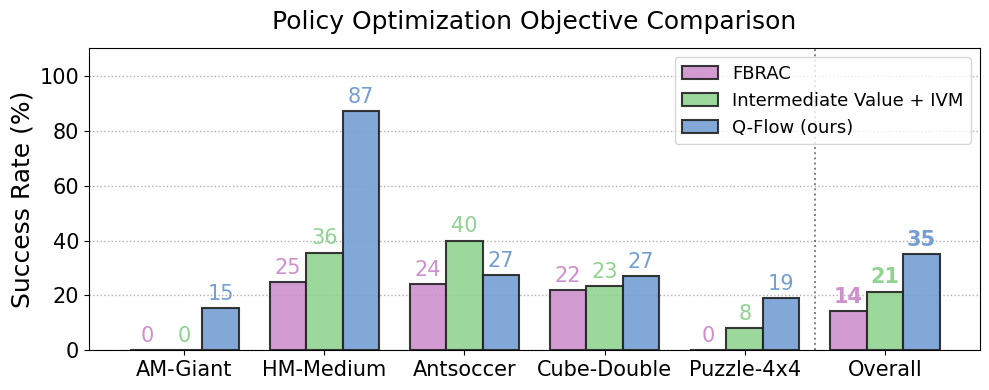

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Task names (cleaned up individual entries) + Overall
tasks = ["AM-Giant", "HM-Medium", "Antsoccer", "Cube-Double", "Puzzle-4x4", "Overall"]

# Updated success rates per task
local_grad = [15.4, 87.1, 27.3, 27, 19]
local_bptt = [0, 35.6, 40, 23.3, 8]
fbrac = [0, 25, 24, 22, 0]

# Compute overall means
overall_local_grad = np.mean(local_grad)
overall_local_bptt = np.mean(local_bptt)
overall_fbrac = np.mean(fbrac)

# Append overall results
local_grad_all = local_grad + [overall_local_grad]
local_bptt_all = local_bptt + [overall_local_bptt]
fbrac_all = fbrac + [overall_fbrac]

# --- Reordering so that FBRAC, Intermediate+IVM, Q-Flow (ours) ---
# Instead of: [bptt, fbrac, ours], we want [fbrac, bptt, ours]
method_names = ["FBRAC", "Intermediate Value + IVM", "Q-Flow (ours)"]
bar_data = [
    fbrac_all,        # index 0: FBRAC
    local_bptt_all,   # index 1: BPTT
    local_grad_all,   # index 2: Ours (Q-Flow)
]
# color map and graphics
colors = {
    "fbrac": "#CD90CD",  # light purple
    "bptt":   "#91D391",  # light green
    "grad": "#749FD4",  # light blue
}

bar_colors = [colors['fbrac'], colors['bptt'], colors['grad']]

edge_color = "#222222"

bar_width = 0.26
group_gap = 0.0
x = np.arange(len(tasks)) * (1 + group_gap)

fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# Draw bars in new order (fbrac, bptt, ours)
rects = []
for i, (data, color) in enumerate(zip(bar_data, bar_colors)):
    offset = (-bar_width if i == 0 else (0 if i == 1 else bar_width))
    method_label = method_names[i]
    rect = ax.bar(
        x + offset, data, bar_width, 
        label=method_label, color=color,
        edgecolor=edge_color, linewidth=1.5, zorder=3, alpha=0.9
    )
    rects.append(rect)

# Optionally highlight the overall bars (bold face and/or thicker edge)
# for bars in rects:
#     bars[-1].set_edgecolor('black')
#     bars[-1].set_alpha(1.0)

# Draw a dotted vertical line to separate envs and "Overall"
sep_idx = len(tasks) - 1
line_x = x[sep_idx] - 0.5 * (1 + group_gap)
ax.axvline(line_x, color="black", linewidth=1.4, linestyle=":", alpha=0.5, zorder=4)

# Set labels and formatting
ax.set_ylabel('Success Rate (%)', fontsize=18)
ax.set_title('Policy Optimization Objective Comparison', fontsize=18, pad=14)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=15)
ax.set_ylim(0, 110)
ax.set_axisbelow(True)
ax.yaxis.grid(True, which="major", linestyle=':', linewidth=1, alpha=1, zorder=0)
ax.tick_params(axis='y', labelsize=15)

ax.legend(loc='upper right', fontsize=13, frameon=True)

# Add annotations for all bars
for i in range(len(tasks)):
    for j in range(3):  # 3 methods
        height = bar_data[j][i]
        bar = rects[j][i]
        fontweight = 'bold' if i == len(tasks) - 1 else 'normal'
        bbox = None
        col = bar_colors[j]
        if height > 0:
            ax.annotate(f'{int(height + 0.5)}', 
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, color=col,
                        fontweight=fontweight, bbox=bbox)
        else:
            ax.annotate('0',
                        xy=(bar.get_x() + bar.get_width() / 2, 0),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, color=col,
                        fontweight=fontweight, bbox=bbox)

plt.tight_layout()
plt.savefig('policy_ablation.pdf', dpi=300)


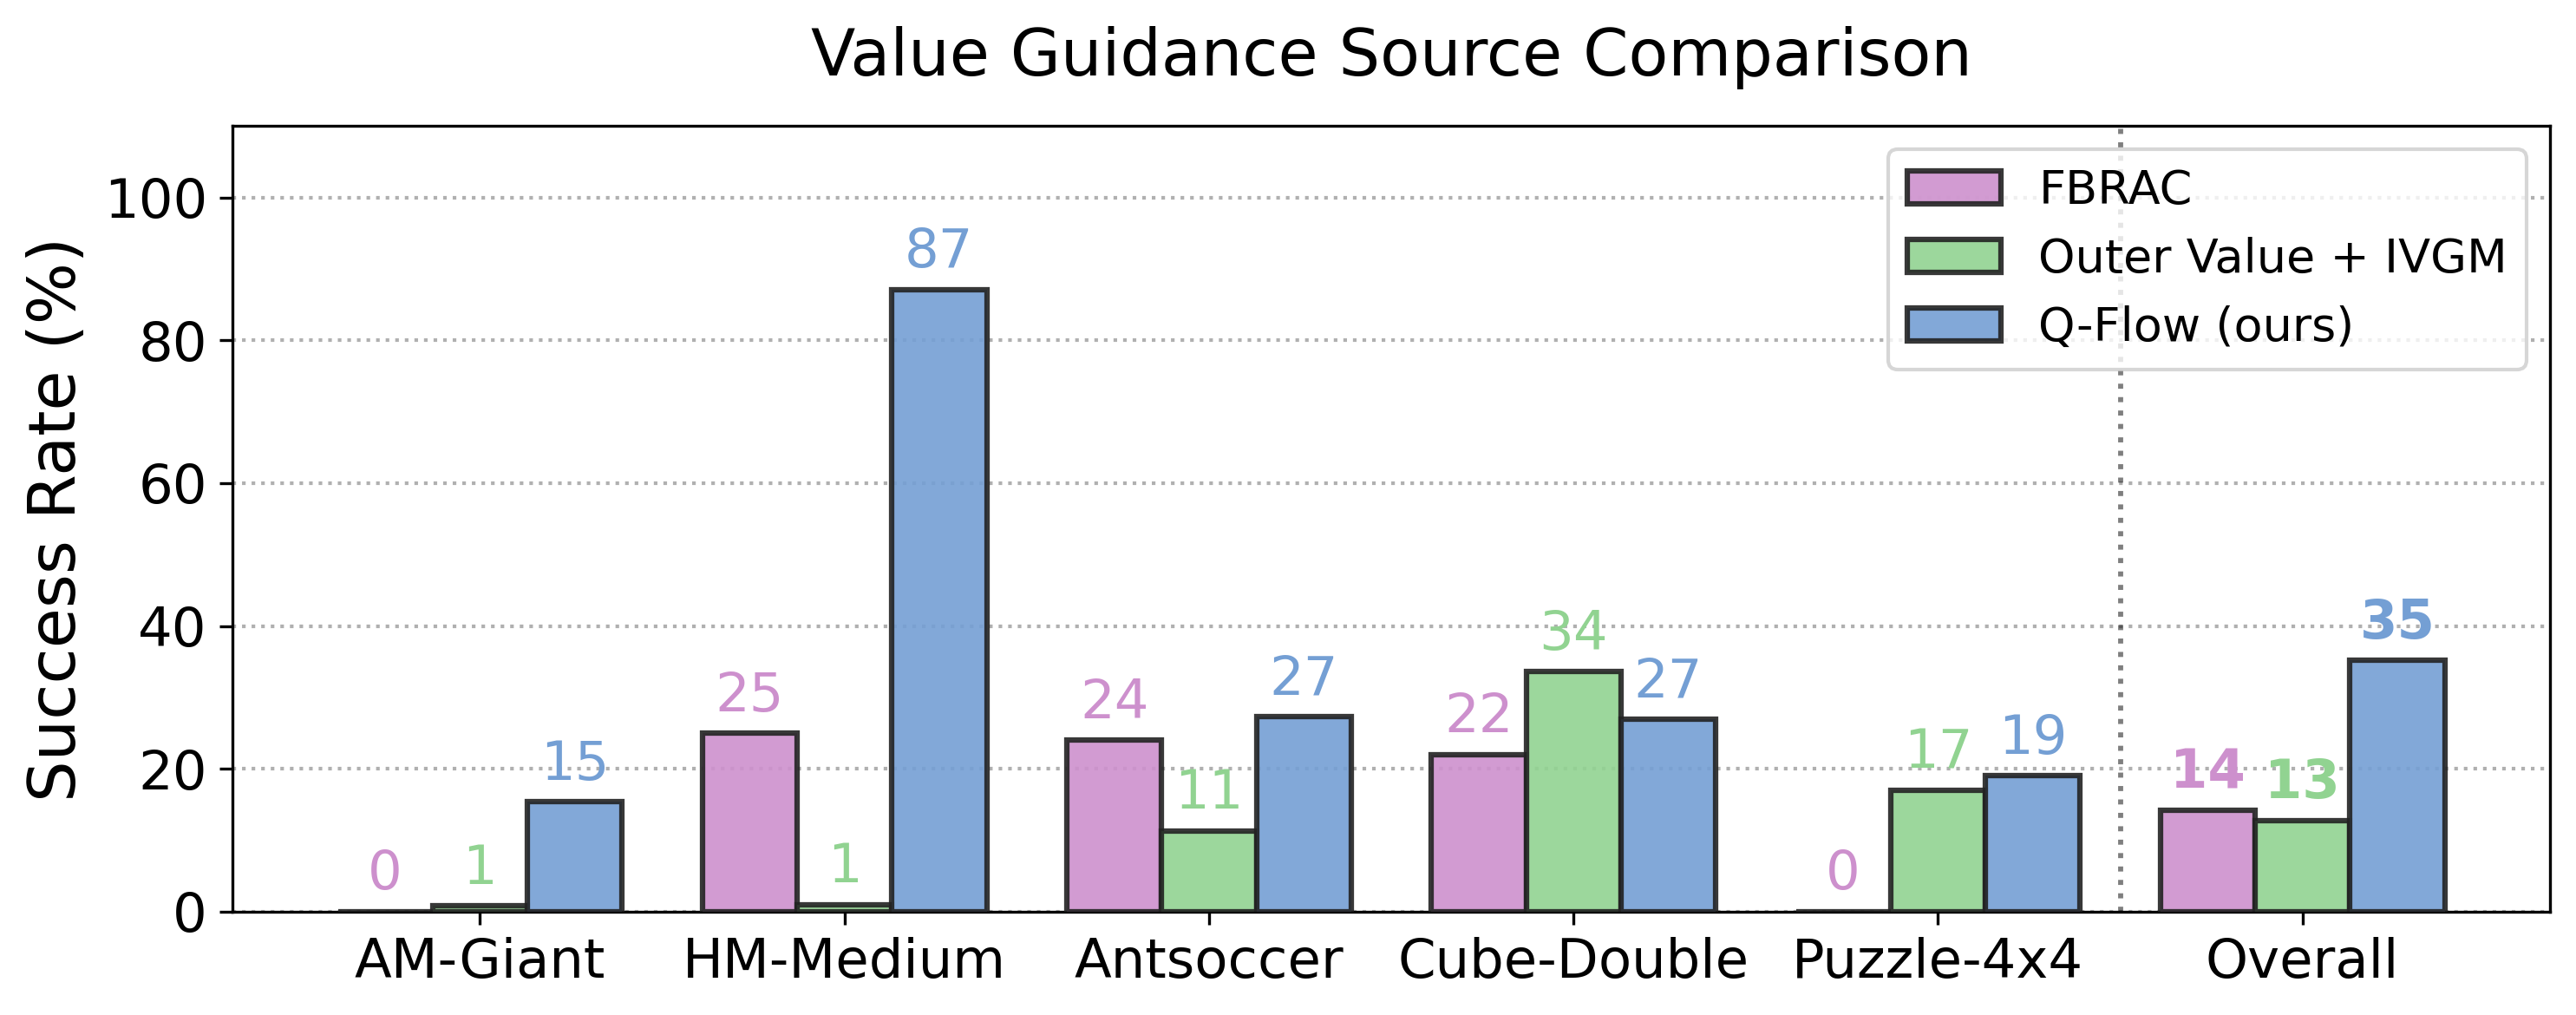

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Task names (cleaned up individual entries) + Overall
tasks = ["AM-Giant", "HM-Medium", "Antsoccer", "Cube-Double", "Puzzle-4x4", "Overall"]

# Raw numbers: keep the variables for clarity, but we'll order them as [FBRAC, Outer Value + IVGM, Q-Flow]
qflow = [15.4, 87.1, 27.3, 27, 19]
fbrac_plus_local = [0.8, 1, 11.3, 33.6, 17]
fbrac_default = [0, 25, 24, 22, 0]

# Compute overall means
overall_qflow = np.mean(qflow)
overall_fbrac_plus_local = np.mean(fbrac_plus_local)
overall_fbrac_default = np.mean(fbrac_default)

# Append overall results
qflow_all = qflow + [overall_qflow]
fbrac_plus_local_all = fbrac_plus_local + [overall_fbrac_plus_local]
fbrac_default_all = fbrac_default + [overall_fbrac_default]

# ---- Reordering: FBRAC, Outer Value + IVGM, Q-Flow ----
plot_methods = [
    ('fbrac', fbrac_default_all, "FBRAC"),
    ('fbrac_plus', fbrac_plus_local_all, "Outer Value + IVGM"),
    ('qflow', qflow_all, "Q-Flow (ours)"),
]

# Increase margin between env bars by increasing x spacing
bar_width = 0.26
group_gap = 0.0  # increased gap between grouped bars
x = np.arange(len(tasks)) * (1 + group_gap)  # spread out x-positions

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Use a colorblind-friendly and print-friendly palette
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in range(3)]

color_map = {
    "fbrac": "#CD90CD",  # light purple
    "fbrac_plus":   "#91D391",  # light green
    "qflow": "#749FD4",  # light blue
}

edge_color = "#222222"

# Draw bars using new order and the appropriate colors/labels
rects_handles = []
for idx, (method_key, values, label) in enumerate(plot_methods):
    offset = (idx - 1) * bar_width
    rects = ax.bar(x + offset, values, bar_width, label=label, color=color_map[method_key],
                   edgecolor=edge_color, linewidth=1.5, zorder=3, alpha=0.9)
    rects_handles.append(rects)

# Optionally highlight the overall bars (bold face and/or thicker edge)
# for rects in rects_handles:
#     rects[-1].set_edgecolor('black')
#     rects[-1].set_alpha(1.0)

# Draw a dotted vertical line to separate envs and "Overall"
sep_idx = len(tasks) - 1  # index of "Overall"
line_x = x[sep_idx] - 0.5 * (1 + group_gap)  # match increased spread
ax.axvline(line_x, color="black", linewidth=1.4, linestyle=":", alpha=0.5, zorder=4)

# Set labels and formatting
ax.set_ylabel('Success Rate (%)', fontsize=18)
ax.set_title('Value Guidance Source Comparison', fontsize=18, pad=14)
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=15)  # keep labels straight (no rotation)
ax.set_ylim(0, 110)
ax.set_axisbelow(True)
ax.yaxis.grid(True, which="major", linestyle=':', linewidth=1, alpha=1, zorder=0)
ax.tick_params(axis='y', labelsize=15)  # Set ytick fontsize

# Put legend inside the plot (upper right), as long as it fits well
ax.legend(loc='upper right', fontsize=13, frameon=True)

# Add annotations to each bar (annotate for 0 success rate as well!)
for i in range(len(tasks)):
    for rects, (_, values, _), method_key in zip(rects_handles, plot_methods, ['fbrac', 'fbrac_plus', 'qflow']):
        rect = rects[i]
        height = rect.get_height()
        col = color_map[method_key]
        # Always annotate, including zero bars
        if i == len(tasks) - 1:
            fontweight = 'bold'
            bbox = None
        else:
            fontweight = 'normal'
            bbox = None
        if height > 0:
            ax.annotate(f'{int(height + 0.5)}', 
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, color=col,
                        fontweight=fontweight, bbox=bbox)
        else:
            ax.annotate('0',
                        xy=(rect.get_x() + rect.get_width() / 2, 0),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=15, color=col,
                        fontweight=fontweight, bbox=bbox)

plt.tight_layout()
plt.savefig('value_ablation.pdf', dpi=300)


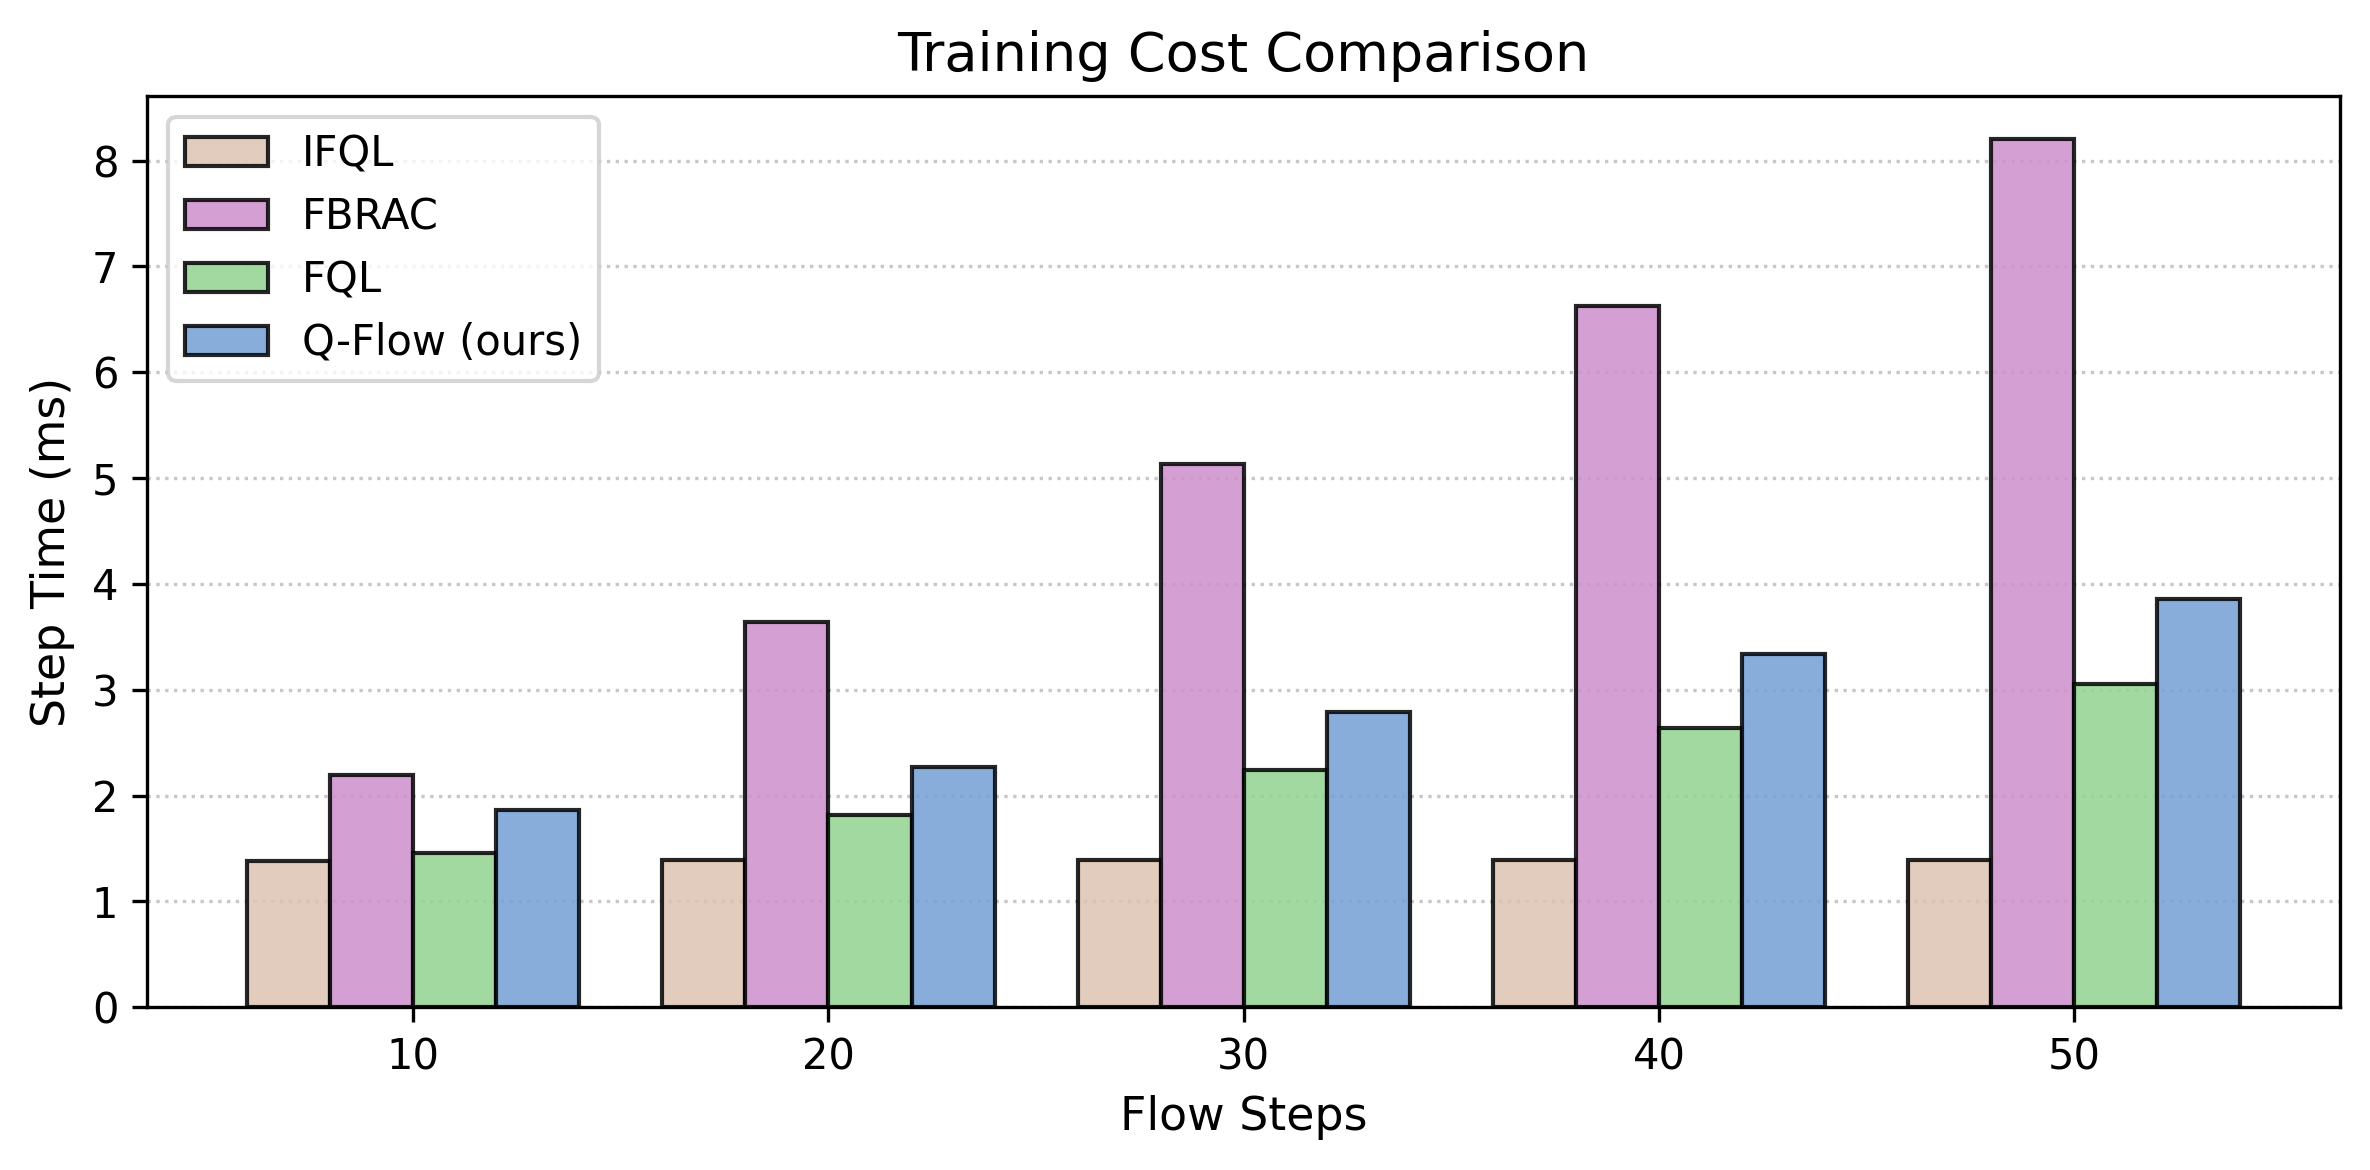

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Data
flow_steps = np.array([10, 20, 30, 40, 50])
ifql_cost = np.array([1.38, 1.39, 1.39, 1.39, 1.39])
fbrac_cost = np.array([2.19, 3.64, 5.13, 6.63, 8.2])
fql_cost = np.array([1.46, 1.82, 2.24, 2.64, 3.05])
qflow_cost = np.array([1.86, 2.27, 2.79, 3.34, 3.86])

# Settings
x = np.arange(len(flow_steps))  # the label locations
width = 0.2  # the width of the bars
colors = ["#DDC3B2", "#CD90CD", "#91D391", "#749FD4"][::-1]


fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

# Create bars (Grouped)
# Order: IFQL (left), FBRAC, FQL, Q-Flow (rightmost)
rects1 = ax.bar(x - 1.5*width, ifql_cost, width, label='IFQL', color=colors[3], edgecolor='black', alpha=0.85)
rects2 = ax.bar(x - 0.5*width, fbrac_cost, width, label='FBRAC', color=colors[2], edgecolor='black', alpha=0.85)
rects3 = ax.bar(x + 0.5*width, fql_cost, width, label='FQL', color=colors[1], edgecolor='black', alpha=0.85)
rects4 = ax.bar(x + 1.5*width, qflow_cost, width, label='Q-Flow (ours)', color=colors[0], edgecolor='black', alpha=0.85)

# Formatting
ax.set_xlabel('Flow Steps', fontsize=11)
ax.set_ylabel('Step Time (ms)', fontsize=11)
ax.set_title('Training Cost Comparison', fontsize=13)
ax.set_xticks(x)

ax.set_xticklabels(flow_steps, fontsize=10)
ax.legend(fontsize=10)

# Set ytick fontsize
ax.tick_params(axis='y', labelsize=10)

# Grid only on Y axis for readability
ax.yaxis.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)


plt.tight_layout()
plt.savefig('training_cost_comparison.pdf', dpi=300, bbox_inches='tight')